# Proceso de ramificación en complejos celulares — simulación

Simulación del modelo de *Branching process on complexes* (D. Cid, A. Sepúlveda, borrador V1, 2026) sobre el complejo cúbico $\mathbb{Z}^d$, restringido a una caja finita.

Una configuración $\theta\in\mathbb{Z}^{E^+}$ asigna a cada arista un número entero de partículas con signo. En cada evento, una partícula sobre $e$ hace sonar una cara $f\ni e$ y la configuración pasa a ser

$$\theta\;\longmapsto\;\theta-\langle e,\partial f\rangle\operatorname{sgn}(\theta_e)\,\partial f .$$

La partícula original se aniquila y nacen otras 3 en el resto del borde de $f$. Las cargas opuestas que coinciden en una arista se cancelan, y las partículas que llegan al conjunto absorbente $T$ mueren.


**Contenido**

1. Complejo cúbico y operadores
2. Absorción
3. Motor estocástico
4. Configuraciones iniciales y reconstrucción
5. Visualización
6. Videos
7. Condición inicial: cuadrado y cubo
8. **Probabilidad de extinción**

In [1]:
import shutil
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import scipy.sparse as sp
from scipy.sparse.csgraph import breadth_first_tree, connected_components, minimum_spanning_tree

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.collections import LineCollection
from IPython.display import Video, Image, display
from functools import partial
from itertools import product
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection
from joblib import Parallel, delayed

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
VIDEO_DIR = Path("videos")
VIDEO_DIR.mkdir(exist_ok=True)
SEED = 2026

## 1. Complejo cúbico y operadores

Cada $k$-celda se identifica con su baricentro en $\tfrac12\mathbb{Z}^d$, que tiene exactamente $k$ coordenadas semienteras. Para trabajar solo con enteros se usan coordenadas dobladas $z=2x$. El borde se calcula con la Def. 1.5 del paper,

$$\partial_k x=\sum_{i\in J_x}\varepsilon_{J_x}(i)\,(x^{+i}-x^{-i}),\qquad \varepsilon_J(s)=(-1)^{\#\{j\in J:\,j<s\}},$$

y se guarda como matriz rala. Los Laplacianos son $\Delta_1^\downarrow=\partial_1^T\partial_1$ y $\Delta_1^\uparrow=\partial_2\partial_2^T$.

In [2]:
def doubled_grid_shape(box_shape):
    """Forma de la grilla doblada {0,...,2n_i}^d que contiene todas las celdas de la caja.

    Una celda con baricentro x ∈ ½Z^d se codifica por el entero z = 2x."""
    return tuple(2 * n + 1 for n in box_shape)


def all_doubled_points(box_shape):
    """Todos los puntos z de la grilla doblada, como arreglo (N, d) de enteros."""
    grid = doubled_grid_shape(box_shape)
    return np.indices(grid).reshape(len(grid), -1).T


def cell_dimensions(points):
    """Dimensión k de cada celda = #{i : z_i impar} = #coordenadas estrictamente semienteras (ec. (1))."""
    return np.count_nonzero(points % 2, axis=1)


def cells_of_dimension(box_shape, k):
    """Lista ordenada (lexicográficamente) de las k-celdas positivas Ξ_k^+ de la caja."""
    points = all_doubled_points(box_shape)
    return points[cell_dimensions(points) == k]


def build_vertices(box_shape):
    """0-celdas Ξ_0^+: puntos enteros de la caja."""
    return cells_of_dimension(box_shape, 0)


def build_edges(box_shape):
    """1-celdas Ξ_1^+: aristas [x, x+e_i] con su orientación canónica (en el sentido de +e_i)."""
    return cells_of_dimension(box_shape, 1)


def build_faces(box_shape):
    """2-celdas Ξ_2^+: caras [x,x+e_i]×[x,x+e_j], i<j, con la orientación heredada de R^d."""
    return cells_of_dimension(box_shape, 2)


def build_cell_lookup(cells, box_shape):
    """Tabla inversa (densa) coordenada doblada -> índice de la celda en `cells` (-1 si no pertenece)."""
    grid = doubled_grid_shape(box_shape)
    lookup = np.full(int(np.prod(grid)), -1, dtype=np.int64)
    lookup[np.ravel_multi_index(cells.T, grid)] = np.arange(len(cells))
    return lookup


def lookup_cells(coords, lookup, box_shape):
    """Índices de las celdas con coordenadas dobladas `coords` (arreglo (m, d)), vectorizado."""
    return lookup[np.ravel_multi_index(np.asarray(coords).T, doubled_grid_shape(box_shape))]


def edge_segments(edges):
    """Extremos (E, 2, 2) de cada arista en coordenadas reales: x ± ½e_i en la dirección impar."""
    odd = edges % 2
    return np.stack([(edges - odd) / 2, (edges + odd) / 2], axis=1)


def edge_midpoints(edges):
    """Baricentros de las aristas en coordenadas reales."""
    return edges / 2

In [3]:
def orientation_sign(cells, i):
    """ε_J(i) = (-1)^{#{j ∈ J : j < i}}, con J = J_x el conjunto de coordenadas impares (dobladas) de cada celda.

    Vectorizado sobre todas las filas de `cells`."""
    below = np.count_nonzero(cells[:, :i] % 2, axis=1)
    return 1 - 2 * (below % 2)


def boundary_entries_in_direction(cells_k, lookup_km1, box_shape, i):
    """Entradas (fila, columna, valor) de ∂_k aportadas por la dirección i ∈ J_x:
    ε_J(i)·(+1) en la celda x^{+i} y ε_J(i)·(-1) en la celda x^{-i}."""
    cols = np.flatnonzero(cells_k[:, i] % 2 == 1)
    x = cells_k[cols]
    shift = np.zeros(cells_k.shape[1], dtype=np.int64)
    shift[i] = 1
    eps = orientation_sign(x, i)
    plus = lookup_cells(x + shift, lookup_km1, box_shape)
    minus = lookup_cells(x - shift, lookup_km1, box_shape)
    return np.concatenate([plus, minus]), np.concatenate([cols, cols]), np.concatenate([eps, -eps])


def boundary_matrix(cells_k, cells_km1, box_shape):
    """Operador de frontera ∂_k : Ω_k -> Ω_{k-1} como matriz rala CSR (Def. 1.5)."""
    lookup = build_cell_lookup(cells_km1, box_shape)
    parts = [boundary_entries_in_direction(cells_k, lookup, box_shape, i) for i in range(cells_k.shape[1])]
    rows, cols, vals = (np.concatenate(p) for p in zip(*parts))
    return sp.csr_matrix((vals, (rows, cols)), shape=(len(cells_km1), len(cells_k)), dtype=np.int64)


def boundary_1(vertices, edges, box_shape):
    """∂_1 (aristas -> vértices): ∂[x, x+e_i] = (x+e_i) - x, cabeza menos cola."""
    return boundary_matrix(edges, vertices, box_shape)


def boundary_2(edges, faces, box_shape):
    """∂_2 (caras -> aristas): borde orientado antihorario de cada cara (Fig. 3)."""
    return boundary_matrix(faces, edges, box_shape)


def coboundary_matrix(boundary_k):
    """Co-frontera / gradiente ∇_k = ∂_k^T : Ω_{k-1} -> Ω_k (Def. 1.6, adjunto de ∂_k)."""
    return boundary_k.T.tocsr()


@dataclass(frozen=True)
class CubicalComplex:
    """Complejo cúbico de la caja [0,n_1]x...x[0,n_d] (2-esqueleto) con sus operadores de frontera."""
    box_shape: tuple
    vertices: np.ndarray  # (V, d) coordenadas dobladas
    edges: np.ndarray     # (E, d)
    faces: np.ndarray     # (F, d)
    d1: sp.csr_matrix     # ∂_1, forma (V, E)
    d2: sp.csr_matrix     # ∂_2, forma (E, F)

    @property
    def dim(self):
        return len(self.box_shape)


def build_cubical_complex(box_shape):
    """Ensambla celdas y matrices de frontera ∂_1, ∂_2 de la caja."""
    box_shape = tuple(int(n) for n in box_shape)
    V, E, F = build_vertices(box_shape), build_edges(box_shape), build_faces(box_shape)
    return CubicalComplex(box_shape, V, E, F, boundary_1(V, E, box_shape), boundary_2(E, F, box_shape))


def chain_complex_defect(boundary_k, boundary_kp1):
    """max |∂_k ∂_{k+1}|, que debe ser exactamente 0 (Lema 1.8)."""
    product = boundary_k @ boundary_kp1
    return 0 if product.nnz == 0 else int(abs(product).max())


def lower_laplacian(boundary_k):
    """Δ_k^↓ = ∇_k ∇_k^T = ∂_k^T ∂_k (acopla k-celdas a través de (k-1)-caras comunes)."""
    return (coboundary_matrix(boundary_k) @ boundary_k).tocsr()


def upper_laplacian(boundary_kp1):
    """Δ_k^↑ = ∇_{k+1}^T ∇_{k+1} = ∂_{k+1} ∂_{k+1}^T (acopla k-celdas a través de (k+1)-celdas comunes)."""
    return (boundary_kp1 @ coboundary_matrix(boundary_kp1)).tocsr()


def hodge_laplacian(lower, upper):
    """Δ_k = Δ_k^↓ + Δ_k^↑ (ec. (4))."""
    return (lower + upper).tocsr()

## 2. Absorción

Las partículas que caen en $T$ mueren, lo que equivale a usar el borde co-restringido $\partial_T=P_T\partial_2$. Las opciones son:

- `"tree"`: un árbol generador aleatorio, que es el caso del paper;
- `"box_boundary"`: las aristas del borde de la caja;
- `"none"`: sin absorción.

`spanning_tree_avoiding_mask` construye un árbol que usa el mínimo número posible de aristas de un conjunto dado; sirve para que el árbol no mate la condición inicial.

In [4]:
def edge_endpoints(d1):
    """(cola, cabeza) de cada arista leídas de ∂_1: la columna e tiene -1 en la cola y +1 en la cabeza."""
    csc = d1.tocsc()
    csc.sort_indices()
    rows, vals = csc.indices.reshape(-1, 2), csc.data.reshape(-1, 2)
    head = np.where(vals[:, 0] > 0, rows[:, 0], rows[:, 1])
    tail = np.where(vals[:, 0] > 0, rows[:, 1], rows[:, 0])
    return tail, head


def edge_face_counts(d2):
    """λ_e = número de caras adyacentes a la arista e (filas no nulas de ∂_2). En el bulk λ_e = 2(d-1)."""
    return np.diff(d2.tocsr().indptr)


def vertex_graph(d1, weights):
    """Matriz de adyacencia ponderada (simétrica, V x V) del 1-esqueleto, con peso `weights[e]` en la arista e."""
    tail, head = edge_endpoints(d1)
    n = d1.shape[0]
    g = sp.coo_matrix((weights, (tail, head)), shape=(n, n)).tocsr()
    return (g + g.T).tocsr()


def tree_matrix_to_edge_mask(tree, d1):
    """Convierte una matriz de árbol de csgraph (V x V) en una máscara booleana sobre las aristas."""
    edge_id = vertex_graph(d1, np.arange(1, d1.shape[1] + 1))
    t = tree.tocoo()
    mask = np.zeros(d1.shape[1], dtype=bool)
    mask[np.asarray(edge_id[t.row, t.col]).ravel() - 1] = True
    return mask


def random_spanning_tree_mask(d1, rng):
    """Árbol generador aleatorio: MST con pesos i.i.d. U(1,2) (Kruskal aleatorizado; no es el árbol uniforme)."""
    weights = 1.0 + rng.random(d1.shape[1])
    return tree_matrix_to_edge_mask(minimum_spanning_tree(vertex_graph(d1, weights)), d1)


def bfs_spanning_tree_mask(d1, root=0):
    """Árbol generador determinista: árbol BFS desde el vértice `root`."""
    tree = breadth_first_tree(vertex_graph(d1, np.ones(d1.shape[1])), root, directed=False)
    return tree_matrix_to_edge_mask(tree, d1)


def spanning_tree_avoiding_mask(d1, avoid, rng):
    """Árbol generador aleatorio que usa el mínimo número posible de aristas de `avoid`.

    Pesos U(1,2) + 2|V|·1_avoid: como todo árbol tiene |V|-1 aristas, la penalización domina la
    suma de pesos base, y el MST minimiza primero el número de aristas penalizadas."""
    penalty = 2.0 * d1.shape[0]
    weights = 1.0 + rng.random(d1.shape[1]) + penalty * avoid
    return tree_matrix_to_edge_mask(minimum_spanning_tree(vertex_graph(d1, weights)), d1)


def box_boundary_edge_mask(cx):
    """Aristas contenidas en el borde de la caja: las que tienen menos de 2(d-1) caras adyacentes."""
    return edge_face_counts(cx.d2) < 2 * (cx.dim - 1)


def no_killing_mask(cx):
    """T = ∅."""
    return np.zeros(len(cx.edges), dtype=bool)


def kill_mask_for_mode(cx, mode, rng=None):
    """Despacha el modo de condición de borde: 'tree' | 'bfs_tree' | 'box_boundary' | 'none'."""
    builders = {
        "tree": lambda: random_spanning_tree_mask(cx.d1, rng if rng is not None else np.random.default_rng()),
        "bfs_tree": lambda: bfs_spanning_tree_mask(cx.d1, root=len(cx.vertices) // 2),
        "box_boundary": lambda: box_boundary_edge_mask(cx),
        "none": lambda: no_killing_mask(cx),
    }
    return builders[mode]()


def is_spanning_tree(mask, d1):
    """Chequea |T| = |V|-1 y que (V, T) sea conexo."""
    sub = vertex_graph(d1[:, mask], np.ones(int(mask.sum())))
    return mask.sum() == d1.shape[0] - 1 and connected_components(sub, directed=False)[0] == 1


def survival_projector(kill_mask):
    """P_T = diag(1_{e ∉ T}): anula las coordenadas sobre las aristas absorbentes."""
    return sp.diags((~kill_mask).astype(np.int64), format="csr", dtype=np.int64)


def co_restricted_boundary(d2, kill_mask):
    """∂_T = P_T ∂_2 (§2.3): borde de cada cara visto solo en las aristas que sobreviven."""
    B = (survival_projector(kill_mask) @ d2).tocsr().astype(np.int64)
    B.eliminate_zeros()
    return B


def restricted_upper_laplacian(d2, kill_mask):
    """Δ^↑ restringido a las 1-formas que se anulan en T: (∂_2 ∂_2^T)[E∖T, E∖T]."""
    keep = ~kill_mask
    return upper_laplacian(d2[keep])


def poincare_constant(d2, kill_mask, tol=1e-9):
    """(c', dim ker): menor autovalor de Δ^↑|_{E∖T} y dimensión de su núcleo (denso; solo para cajas chicas)."""
    ev = np.linalg.eigvalsh(restricted_upper_laplacian(d2, kill_mask).toarray().astype(float))
    return ev[0], int(np.sum(ev < tol))


def divergence(theta, d1):
    """∂_1 θ: carga neta en cada vértice (ver §4)."""
    return d1 @ theta

## 3. Motor estocástico

Cada par (partícula, cara adyacente) tiene tasa $1$. En cada paso:

1. se elige la arista $e$ con probabilidad $\propto|\theta_e|\lambda_e$;
2. se elige una cara $f\ni e$ uniforme;
3. se calcula $c=\langle e,\partial f\rangle\operatorname{sgn}(\theta_e)$ y se actualiza $\theta\leftarrow\theta-c\,\partial_Tf$. La aniquilación ocurre sola, porque es suma en $\mathbb{Z}$;
4. el reloj avanza $\tau\sim\mathrm{Exp}(\langle|\theta|,\lambda\rangle)$ (algoritmo de Gillespie).

El historial guarda solo $(f_t,c_t)$, que es el proceso de alturas $\eta$, y $\theta_t=\theta_0+\partial_T\eta_t$ se reconstruye después. La simulación termina cuando hay extinción, cuando se agotan `n_steps` eventos o cuando el tiempo supera `t_max`.

In [5]:
def particle_weights(theta, lam, clock):
    """Pesos de selección de la arista detonante: |θ_e|·λ_e ('generator') o |θ_e| ('per_particle')."""
    w = np.abs(theta).astype(np.float64)
    return w * lam if clock == "generator" else w


def sample_edge(weights, total, rng):
    """Muestreo ponderado de la arista detonante, P(e) = w_e / Σ w."""
    return rng.choice(len(weights), p=weights / total)


def sample_adjacent_face(e, B_csr, rng):
    """Cara f uniforme entre las caras adyacentes a e, junto con la incidencia ⟨e, ∂f⟩ ∈ {±1}.

    Usa la fila e de ∂_T en CSR. Para e ∉ T esa fila coincide con la fila de ∂_2."""
    start, stop = B_csr.indptr[e], B_csr.indptr[e + 1]
    j = start + rng.integers(stop - start)
    return B_csr.indices[j], B_csr.data[j]


def ring_charge(theta_e, incidence):
    """c = ⟨e, ∂f⟩ · sgn(θ_e): elige el signo de modo que la partícula detonante reciba -sgn(θ_e)."""
    return int(incidence * np.sign(theta_e))


def incoming_charges(f, c, B_csc):
    """Aristas sobrevivientes del borde de f y cargas que reciben: -c·∂_T f."""
    start, stop = B_csc.indptr[f], B_csc.indptr[f + 1]
    return B_csc.indices[start:stop], -c * B_csc.data[start:stop]


def count_annihilations(theta_on_edges, charges):
    """Número de cargas entrantes de signo opuesto a la ocupación actual (cada una cancela una partícula)."""
    return int(np.count_nonzero(theta_on_edges * charges < 0))


def apply_charges(theta, edges, charges):
    """Suma entera θ_e += carga. La aritmética en Z implementa la aniquilación (+1) + (-1) = 0.
    Modifica el búfer de trabajo in situ."""
    theta[edges] += charges


def killed_per_face(d2, B):
    """Número de aristas de ∂f que caen en T, es decir, partículas que mueren cuando suena f."""
    return np.diff(d2.tocsc().indptr) - np.diff(B.tocsc().indptr)


def holding_time(total_rate, rng):
    """Tiempo de espera del reloj de Gillespie, τ ~ Exp(tasa total)."""
    return rng.exponential(1.0 / total_rate)


def project_out_killed(theta0, kill_mask):
    """Copia de θ_0 con las coordenadas en T anuladas (θ_0 ∈ Θ_T)."""
    theta = np.array(theta0, dtype=np.int64, copy=True)
    theta[kill_mask] = 0
    return theta


def read_only(array):
    """Devuelve el arreglo marcado como inmutable."""
    array.setflags(write=False)
    return array

In [6]:
@dataclass(frozen=True)
class EventLog:
    """Registro preasignado (append-only) de la trayectoria. Ocupa O(n_steps) y es independiente de |E|."""
    faces: np.ndarray          # f_t que sonó (int32)
    charges: np.ndarray        # c_t ∈ {±1} (int8)
    times: np.ndarray          # tiempo continuo t_0=0, t_1, ... (n_steps+1)
    l1: np.ndarray             # ‖θ_t‖_1 (n_steps+1)
    l2sq: np.ndarray           # ‖θ_t‖_2^2 (n_steps+1)
    annihilations: np.ndarray  # aniquilaciones en el paso t
    kills: np.ndarray          # partículas absorbidas en T en el paso t


def allocate_event_log(n_steps):
    """Reserva memoria una sola vez para todo el horizonte de simulación."""
    return EventLog(
        faces=np.empty(n_steps, np.int32), charges=np.empty(n_steps, np.int8),
        times=np.empty(n_steps + 1), l1=np.empty(n_steps + 1, np.int64), l2sq=np.empty(n_steps + 1, np.int64),
        annihilations=np.empty(n_steps, np.int32), kills=np.empty(n_steps, np.int32),
    )


def record_state(log, t, time, theta):
    """Guarda observables escalares del estado en el instante t."""
    log.times[t], log.l1[t], log.l2sq[t] = time, np.abs(theta).sum(), np.dot(theta, theta)


def record_event(log, t, f, c, n_annihilated, n_killed):
    """Guarda el evento del paso t, que alcanza para reconstruir θ."""
    log.faces[t], log.charges[t], log.annihilations[t], log.kills[t] = f, c, n_annihilated, n_killed


def trim_event_log(log, n_done):
    """Recorta el registro a los n_done pasos efectivamente simulados y lo deja como solo lectura."""
    return EventLog(*(read_only(arr[: n_done + (1 if arr.shape[0] == log.times.shape[0] else 0)].copy())
                      for arr in (log.faces, log.charges, log.times, log.l1, log.l2sq, log.annihilations, log.kills)))


@dataclass(frozen=True)
class SimulationResult:
    """Salida inmutable del motor."""
    cx: CubicalComplex
    kill_mask: np.ndarray
    B: sp.csr_matrix       # ∂_T
    theta0: np.ndarray     # configuración inicial (ya proyectada a Θ_T)
    theta_final: np.ndarray
    log: EventLog
    clock: str
    random_seed: object

    @property
    def n_steps(self):
        return len(self.log.faces)

    @property
    def extinct(self):
        return self.log.l1[-1] == 0

In [7]:
def run_branching_process(theta0, n_steps, cx, kill_mask=None, random_seed=None, clock="generator", t_max=np.inf):
    """Simula el proceso de ramificación con absorción en T.

    Parámetros
    ----------
    theta0      : configuración inicial θ_0 ∈ Z^{E+} (vector de cargas en las aristas).
    n_steps     : número máximo de eventos.
    cx          : CubicalComplex.
    kill_mask   : máscara booleana de T (por defecto T = ∅).
    random_seed : semilla (o Generator) para np.random.default_rng (reproducibilidad).
    clock       : 'generator' (tasa 1 por par partícula-cara, como el generador L) o 'per_particle'.
    t_max       : horizonte de tiempo continuo; la simulación se corta (censura) al superarlo.
    """
    rng = np.random.default_rng(random_seed)
    kill_mask = no_killing_mask(cx) if kill_mask is None else np.asarray(kill_mask, bool)
    B = co_restricted_boundary(cx.d2, kill_mask)
    B_csr, B_csc = B, B.tocsc()
    lam = edge_face_counts(cx.d2)
    kills_of_face = killed_per_face(cx.d2, B)

    theta = project_out_killed(theta0, kill_mask)  # búfer de trabajo privado
    theta_init = read_only(theta.copy())
    log = allocate_event_log(n_steps)
    time, t = 0.0, 0
    record_state(log, 0, time, theta)

    for t in range(n_steps):  # único bucle: la evolución temporal de la cadena de Markov
        weights = particle_weights(theta, lam, clock)
        total = weights.sum()
        if total == 0 or time >= t_max:  # extinción o censura por tiempo
            break
        e = sample_edge(weights, total, rng)
        f, incidence = sample_adjacent_face(e, B_csr, rng)
        c = ring_charge(theta[e], incidence)
        edges, charges = incoming_charges(f, c, B_csc)
        n_annihilated = count_annihilations(theta[edges], charges)
        apply_charges(theta, edges, charges)
        time += holding_time(total, rng)
        record_event(log, t, f, c, n_annihilated, kills_of_face[f])
        record_state(log, t + 1, time, theta)
    else:
        t = n_steps

    return SimulationResult(cx, read_only(kill_mask.copy()), B, theta_init, read_only(theta),
                            trim_event_log(log, t), clock, random_seed)

## 4. Configuraciones iniciales y reconstrucción de la trayectoria

Funciones disponibles:

- una partícula o cargas puntuales;
- partículas aleatorias;
- un lazo $\partial_2(\text{bloque})$;
- el cuadrado o cubo unitario con $+1$ en sus aristas;
- un bloque de lado $s$ relleno al azar.

La reconstrucción calcula $\theta_t=\theta_0+\partial_T\eta_t$ para todos los cuadros con una sola multiplicación matricial.

In [8]:
def edge_index_at(cx, coords):
    """Índices de las aristas con baricentros `coords` (coordenadas reales semienteras, forma (m, d))."""
    doubled = np.rint(2 * np.atleast_2d(coords)).astype(np.int64)
    return lookup_cells(doubled, build_cell_lookup(cx.edges, cx.box_shape), cx.box_shape)


def point_charge_configuration(cx, coords, charges):
    """θ_0 con cargas `charges` en las aristas de baricentros `coords`."""
    return np.bincount(edge_index_at(cx, coords), weights=charges, minlength=len(cx.edges)).astype(np.int64)


def central_edges(cx, radius):
    """Índices de las aristas cuyo baricentro está a distancia ℓ∞ ≤ radius del centro de la caja."""
    center = np.array(cx.box_shape) / 2
    return np.flatnonzero(np.abs(cx.edges / 2 - center).max(axis=1) <= radius)


def random_configuration(cx, n_particles, rng, support=None):
    """n_particles partículas de signo ±1 uniforme sobre aristas uniformes de `support`.
    Las que caen en la misma arista se suman, de modo que las cargas opuestas se cancelan desde el inicio."""
    support = np.arange(len(cx.edges)) if support is None else support
    where = rng.choice(support, size=n_particles)
    signs = rng.choice([-1, 1], size=n_particles)
    return np.bincount(where, weights=signs, minlength=len(cx.edges)).astype(np.int64)


def face_block_mask(cx, lo, hi):
    """Caras cuyo baricentro está en el bloque [lo, hi]^d."""
    bary = cx.faces / 2
    return np.all((bary >= lo) & (bary <= hi), axis=1)


def loop_configuration(cx, lo, hi, charge=1):
    """θ_0 = charge · ∂_2(Σ caras del bloque): un lazo cerrado de partículas, con ∂_1 θ_0 = 0."""
    return charge * (cx.d2 @ face_block_mask(cx, lo, hi).astype(np.int64))


def planar_face_block_mask(cx, lo, hi, normal_axis, level):
    """Caras perpendiculares a `normal_axis`, en el plano x_normal = level, con baricentro en [lo, hi]."""
    bary = cx.faces / 2
    in_plane = (cx.faces[:, normal_axis] % 2 == 0) & np.isclose(bary[:, normal_axis], level)
    others = np.delete(bary, normal_axis, axis=1)
    return in_plane & np.all((others >= lo) & (others <= hi), axis=1)


def planar_loop_configuration(cx, lo, hi, normal_axis, level, charge=1):
    """θ_0 = charge · ∂_2(caras de un bloque plano): un lazo cerrado con ∂_1 θ_0 = 0."""
    return charge * (cx.d2 @ planar_face_block_mask(cx, lo, hi, normal_axis, level).astype(np.int64))


def centered_block_corner(cx, side):
    """Esquina inferior a del bloque [a, a+side]^d centrado en la caja (coordenadas reales enteras)."""
    return (np.array(cx.box_shape) - side) // 2


def block_edges_mask(cx, corner, side):
    """Aristas contenidas en el bloque cerrado [corner, corner+side]^d (baricentro dentro del bloque)."""
    bary = edge_midpoints(cx.edges)
    return np.all((bary >= corner) & (bary <= corner + side), axis=1)


def unit_block_configuration(cx):
    """θ_0 = +1 en cada arista del cuadrado (d=2) o cubo (d=3) unitario central, con orientación canónica."""
    return block_edges_mask(cx, centered_block_corner(cx, 1), 1).astype(np.int64)


def random_block_configuration(cx, side, p, rng):
    """θ_0 = +1 en cada arista del bloque central de lado `side`, de forma independiente con probabilidad p."""
    mask = block_edges_mask(cx, centered_block_corner(cx, side), side)
    return (mask & (rng.random(len(cx.edges)) < p)).astype(np.int64)

In [9]:
def frame_steps(n_done, n_frames):
    """Instantes (en número de eventos) en que se toma un cuadro, equiespaciados en [0, n_done]."""
    return np.unique(np.linspace(0, n_done, min(n_frames, n_done + 1)).round().astype(np.int64))


def heights_at_steps(log, steps, n_faces):
    """Alturas η_t para t ∈ steps (forma (m, F)). Proceso de alturas de §2.2: η_t = -Σ_{s<t} c_s 1_{f_s}.

    El evento s pertenece al primer cuadro j con steps[j] > s; luego se suma acumulativamente."""
    s = np.arange(len(log.faces))
    bins = np.searchsorted(steps, s, side="right")
    inc = sp.coo_matrix((-log.charges.astype(np.int64), (bins, log.faces)), shape=(len(steps) + 1, n_faces))
    return np.cumsum(inc.toarray(), axis=0)[: len(steps)]


def configurations_from_heights(theta0, heights, B):
    """θ_t = θ_0 + ∂_T η_t para todas las filas de `heights` a la vez (forma (m, E))."""
    return theta0[None, :] + (B @ heights.T).T


def reconstruct_trajectory(result, n_frames=200):
    """(steps, H, Θ): instantes, alturas y configuraciones, listos para animar."""
    steps = frame_steps(result.n_steps, n_frames)
    H = heights_at_steps(result.log, steps, len(result.cx.faces))
    return steps, H, configurations_from_heights(result.theta0, H, result.B)

## 5. Visualización

La convención visual es la misma en 2D y en 3D:

- partículas $+$ en rojo y $-$ en azul;
- el proceso de alturas $\eta$ de fondo (en 3D, como placas translúcidas);
- el conjunto absorbente $T$ en gris;
- a la derecha, $\|\theta_t\|_1$ y las aniquilaciones y absorciones acumuladas.

In [10]:
POS_RGBA = np.array([0.84, 0.15, 0.16, 1.0])


NEG_RGBA = np.array([0.13, 0.40, 0.76, 1.0])


def face_image(values, faces, box_shape):
    """Reacomoda un vector sobre caras como imagen (n_2, n_1) para imshow (solo d = 2)."""
    img = np.zeros((box_shape[1], box_shape[0]))
    img[(faces[:, 1] - 1) // 2, (faces[:, 0] - 1) // 2] = values
    return img


def charge_rgba(theta):
    """Color por signo de la carga; las aristas vacías quedan transparentes."""
    rgba = np.zeros((len(theta), 4))
    rgba[theta > 0], rgba[theta < 0] = POS_RGBA, NEG_RGBA
    return rgba


def draw_lattice_background(ax, segments, kill_mask):
    """Reticulado tenue y conjunto absorbente T resaltado."""
    ax.add_collection(LineCollection(segments[~kill_mask], colors="0.82", linewidths=0.6, zorder=1))
    ax.add_collection(LineCollection(segments[kill_mask], colors="0.35", linewidths=1.8, zorder=1))


def init_height_layer(ax, box_shape, vmax):
    """Capa del proceso de alturas η (imshow con norma simétrica)."""
    return ax.imshow(np.zeros(box_shape[::-1]), origin="lower", extent=(0, box_shape[0], 0, box_shape[1]),
                     cmap="PuOr_r", vmin=-vmax, vmax=vmax, alpha=0.45, zorder=0, interpolation="nearest")


def init_particle_layers(ax, segments):
    """Segmentos coloreados por carga y marcadores en los baricentros."""
    lines = LineCollection(segments, linewidths=2.4, colors=np.zeros((len(segments), 4)), zorder=2)
    ax.add_collection(lines)
    dots = ax.scatter(np.empty(0), np.empty(0), s=np.empty(0), zorder=3, edgecolors="white", linewidths=0.5)
    return lines, dots


def update_particle_layers(lines, dots, theta, midpoints, marker_scale=26.0):
    """Actualiza colores, posiciones y tamaños según θ_t."""
    occupied = theta != 0
    lines.set_color(charge_rgba(theta))
    dots.set_offsets(midpoints[occupied])
    dots.set_sizes(marker_scale * np.sqrt(np.abs(theta[occupied])))
    dots.set_facecolor(charge_rgba(theta)[occupied])


def init_norm_panel(ax, log):
    """‖θ_t‖_1 versus número de eventos, con cursor vertical."""
    ax.plot(np.arange(len(log.l1)), log.l1, color="k", lw=1.1)
    ax.set_ylabel(r"$\|\theta_t\|_1$ (partículas)")
    return ax.axvline(0, color="C3", lw=1)


def init_counts_panel(ax, log):
    """Aniquilaciones y absorciones acumuladas versus número de eventos, con cursor vertical."""
    t = np.arange(1, len(log.l1))
    ax.plot(t, np.cumsum(log.annihilations), color="C1", lw=1, label="aniquilaciones acum.")
    ax.plot(t, np.cumsum(log.kills), color="0.45", lw=1, label="absorciones en T acum.")
    ax.set_xlabel("evento"); ax.legend(frameon=False, fontsize=8, loc="upper left")
    return ax.axvline(0, color="C3", lw=1)


def build_animation_figure(cx, kill_mask, vmax_height, log, title):
    """Figura con el complejo (izquierda) y dos series de tiempo apiladas (derecha)."""
    fig = plt.figure(figsize=(12, 5.6))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1], hspace=0.12)
    ax, ax_n, ax_c = fig.add_subplot(gs[:, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])
    ax_n.sharex(ax_c); ax_n.tick_params(labelbottom=False)
    ax.set_xlim(-0.3, cx.box_shape[0] + 0.3); ax.set_ylim(-0.3, cx.box_shape[1] + 0.3)
    ax.set_aspect("equal"); ax.axis("off")
    segments = edge_segments(cx.edges)
    draw_lattice_background(ax, segments, kill_mask)
    layers = {
        "height": init_height_layer(ax, cx.box_shape, vmax_height),
        "particles": init_particle_layers(ax, segments),
        "cursors": [init_norm_panel(ax_n, log), init_counts_panel(ax_c, log)],
        "label": ax.set_title("", fontsize=10),
    }
    fig.suptitle(title, fontsize=11)
    fig.subplots_adjust(left=0.02, right=0.98, top=0.9, bottom=0.1, wspace=0.12)
    return fig, layers


def make_frame_updater(cx, result, layers, steps, H, Theta):
    """Cierra sobre los datos precomputados y devuelve la función update(j) de FuncAnimation."""
    midpoints = edge_midpoints(cx.edges)
    lines, dots = layers["particles"]

    def update(j):
        layers["height"].set_data(face_image(H[j], cx.faces, cx.box_shape))
        update_particle_layers(lines, dots, Theta[j], midpoints)
        for cursor in layers["cursors"]:
            cursor.set_xdata([steps[j], steps[j]])
        layers["label"].set_text(f"evento {steps[j]}   t = {result.log.times[steps[j]]:.2f}   "
                                 f"partículas = {np.abs(Theta[j]).sum()}")
        return lines, dots, layers["height"], *layers["cursors"]
    return update


def animate_process(result, n_frames=200, fps=20, title=""):
    """Compila la animación de la trayectoria (requiere d = 2)."""
    assert result.cx.dim == 2, "la visualización está implementada para Z^2"
    steps, H, Theta = reconstruct_trajectory(result, n_frames)
    vmax = max(1, np.abs(H).max())
    fig, layers = build_animation_figure(result.cx, result.kill_mask, vmax, result.log, title)
    update = make_frame_updater(result.cx, result, layers, steps, H, Theta)
    anim = animation.FuncAnimation(fig, update, frames=len(steps), interval=1000 / fps, blit=False)
    return fig, anim


def save_animation(anim, path, fps=20):
    """Guarda en MP4 (ffmpeg) o, si ffmpeg no está disponible, en GIF (Pillow). Devuelve la ruta final."""
    path = Path(path)
    if shutil.which("ffmpeg") and path.suffix == ".mp4":
        anim.save(path, writer=animation.FFMpegWriter(fps=fps, bitrate=2400))
    else:
        path = path.with_suffix(".gif")
        anim.save(path, writer=animation.PillowWriter(fps=fps))
    return path


def render_video(result, path, n_frames=200, fps=20, title=""):
    """Pipeline completo: animación, guardado y cierre de la figura."""
    fig, anim = animate_process(result, n_frames, fps, title)
    out = save_animation(anim, path, fps)
    plt.close(fig)
    return out


def show_video(path, width=900):
    """Muestra el video (o GIF) en el notebook."""
    return Video(str(path), width=width) if Path(path).suffix == ".mp4" else Image(filename=str(path))

In [11]:
def face_polygons(faces):
    """Vértices (F, 4, d) de cada cara en coordenadas reales, en el orden de su borde orientado."""
    odd = faces % 2 == 1
    d = faces.shape[1]
    i = np.argmax(odd, axis=1)                    # primera dirección semientera
    j = d - 1 - np.argmax(odd[:, ::-1], axis=1)   # última dirección semientera
    a, b = np.eye(d)[i] / 2, np.eye(d)[j] / 2
    c = faces / 2
    return np.stack([c - a - b, c + a - b, c + a + b, c - a + b], axis=1)


def box_wireframe_segments(box_shape):
    """Las 12 aristas del contorno de la caja (pares de esquinas que difieren en una coordenada)."""
    corners = np.array(list(product(*[(0, n) for n in box_shape])), dtype=float)
    diff = np.count_nonzero(corners[:, None, :] != corners[None, :, :], axis=2)
    p, q = np.nonzero(np.triu(diff == 1))
    return np.stack([corners[p], corners[q]], axis=1)


def height_rgba(heights, vmax, alpha=0.10, cmap=plt.get_cmap("PuOr_r")):
    """Color de las placas según el valor de η (norma simétrica), con transparencia fija."""
    rgba = cmap(Normalize(-vmax, vmax)(heights))
    rgba[:, 3] = alpha
    return rgba


def init_3d_axes(ax, box_shape, kill_mask, segments):
    """Ejes 3D con la caja, el árbol T tenue y las proporciones correctas."""
    ax.set_box_aspect(box_shape)
    for setter, n in zip((ax.set_xlim, ax.set_ylim, ax.set_zlim), box_shape):
        setter(0, n)
    ax.set_axis_off()
    ax.add_collection3d(Line3DCollection(box_wireframe_segments(box_shape), colors="k", linewidths=0.8))
    ax.add_collection3d(Line3DCollection(segments[kill_mask], colors=(0.3, 0.3, 0.3, 0.12), linewidths=0.5))


def init_height_layer_3d(ax):
    """Colección (vacía) de placas del proceso de alturas."""
    poly = Poly3DCollection([], linewidths=0)
    ax.add_collection3d(poly, autolim=False)
    return poly


def init_particle_layers_3d(ax):
    """Segmentos y marcadores (vacíos) de las partículas."""
    lines = Line3DCollection([], linewidths=2.2)
    ax.add_collection3d(lines, autolim=False)
    dots = ax.scatter([], [], [], s=[], depthshade=False, edgecolors="white", linewidths=0.4)
    return lines, dots


def update_height_layer_3d(poly, heights, polygons, vmax):
    """Muestra solo las caras con η(f) ≠ 0."""
    nz = heights != 0
    poly.set_verts(polygons[nz])
    poly.set_facecolor(height_rgba(heights[nz], vmax))


def update_particle_layers_3d(lines, dots, theta, segments, midpoints, marker_scale=22.0):
    """Dibuja solo las aristas ocupadas, coloreadas por carga."""
    occ = theta != 0
    colors = charge_rgba(theta)[occ]
    lines.set_segments(segments[occ])
    lines.set_color(colors)
    dots._offsets3d = tuple(midpoints[occ].T)
    dots.set_sizes(marker_scale * np.sqrt(np.abs(theta[occ])))
    dots.set_facecolor(colors)


def build_animation_figure_3d(cx, kill_mask, log, title):
    """Figura con el complejo 3D (izquierda) y las series de tiempo (derecha)."""
    fig = plt.figure(figsize=(12, 5.8))
    gs = fig.add_gridspec(2, 2, width_ratios=[1.25, 1], hspace=0.12)
    ax = fig.add_subplot(gs[:, 0], projection="3d")
    ax_n, ax_c = fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])
    ax_n.sharex(ax_c); ax_n.tick_params(labelbottom=False)
    init_3d_axes(ax, cx.box_shape, kill_mask, edge_segments(cx.edges))
    layers = {
        "ax": ax,
        "height": init_height_layer_3d(ax),
        "particles": init_particle_layers_3d(ax),
        "cursors": [init_norm_panel(ax_n, log), init_counts_panel(ax_c, log)],
        "label": ax.set_title("", fontsize=10),
    }
    fig.suptitle(title, fontsize=11)
    fig.subplots_adjust(left=0.0, right=0.98, top=0.9, bottom=0.1, wspace=0.08)
    return fig, layers


def make_frame_updater_3d(cx, result, layers, steps, H, Theta, vmax, azim0=-60, rotation=90, elev=24):
    """Función update(j) para la animación 3D (con rotación de cámara de `rotation` grados en total)."""
    segments, midpoints, polygons = edge_segments(cx.edges), edge_midpoints(cx.edges), face_polygons(cx.faces)
    lines, dots = layers["particles"]
    n = max(len(steps) - 1, 1)

    def update(j):
        update_height_layer_3d(layers["height"], H[j], polygons, vmax)
        update_particle_layers_3d(lines, dots, Theta[j], segments, midpoints)
        layers["ax"].view_init(elev=elev, azim=azim0 + rotation * j / n)
        for cursor in layers["cursors"]:
            cursor.set_xdata([steps[j], steps[j]])
        layers["label"].set_text(f"evento {steps[j]}   t = {result.log.times[steps[j]]:.2f}   "
                                 f"partículas = {np.abs(Theta[j]).sum()}")
        return lines, dots, layers["height"], *layers["cursors"]
    return update


def animate_process_3d(result, n_frames=200, fps=20, title="", rotation=90):
    """Compila la animación de una trayectoria en Z^3."""
    assert result.cx.dim == 3, "esta visualización es para Z^3"
    steps, H, Theta = reconstruct_trajectory(result, n_frames)
    vmax = max(1, np.abs(H).max())
    fig, layers = build_animation_figure_3d(result.cx, result.kill_mask, result.log, title)
    update = make_frame_updater_3d(result.cx, result, layers, steps, H, Theta, vmax, rotation=rotation)
    return fig, animation.FuncAnimation(fig, update, frames=len(steps), interval=1000 / fps, blit=False)


def render_video_3d(result, path, n_frames=200, fps=20, title="", rotation=90):
    """Pipeline 3D: animación, guardado y cierre de la figura."""
    fig, anim = animate_process_3d(result, n_frames, fps, title, rotation)
    out = save_animation(anim, path, fps)
    plt.close(fig)
    return out


def adaptive_fps(n_frames_effective, target_seconds=10, max_fps=20, min_fps=2):
    """fps para que el video dure ~target_seconds aunque la trayectoria tenga pocos eventos."""
    return int(np.clip(round(n_frames_effective / target_seconds), min_fps, max_fps))


def render_any_dimension(result, path, n_frames, title):
    """Elige el renderizador 2D o 3D según la dimensión, con fps adaptativo. Devuelve la ruta del video."""
    fps = adaptive_fps(len(frame_steps(result.n_steps, n_frames)))
    if result.cx.dim == 2:
        return render_video(result, path, n_frames=n_frames, fps=fps, title=title)
    return render_video_3d(result, path, n_frames=n_frames, fps=fps, title=title)

## 6. Videos

### Video A — $\mathbb{Z}^2$, absorción en un árbol generador

Caja $16\times16$ con 60 partículas de signo aleatorio cerca del centro.

In [12]:
cx = build_cubical_complex((16, 16))
rng = np.random.default_rng(SEED)
T_tree = kill_mask_for_mode(cx, "tree", rng)
theta0 = random_configuration(cx, 60, rng, support=central_edges(cx, 3))
res = run_branching_process(theta0, n_steps=20_000, cx=cx, kill_mask=T_tree, random_seed=SEED)
print(f"eventos: {res.n_steps}   extinto: {res.extinct}   tiempo final: {res.log.times[-1]:.2f}")

out_a = render_video(res, VIDEO_DIR / "ramificacion_arbol.mp4", n_frames=240, fps=20,
                     title="Killing en un árbol generador aleatorio — caja 16×16")
show_video(out_a)

eventos: 13917   extinto: True   tiempo final: 1549.82


### Video B — $\mathbb{Z}^2$, absorción en el borde de la caja

La condición inicial es el lazo $\theta_0=\partial_2(\text{bloque }4\times4)$, que tiene divergencia nula. Se ve que las partículas forman las fronteras de las regiones del proceso de alturas $\eta$, porque $\theta_t=\theta_0+\partial\eta_t$.

In [13]:
cx_b = build_cubical_complex((24, 24))
T_box = kill_mask_for_mode(cx_b, "box_boundary")
theta0_b = loop_configuration(cx_b, 10, 14)
res_b = run_branching_process(theta0_b, n_steps=6000, cx=cx_b, kill_mask=T_box, random_seed=SEED)
print(f"eventos: {res_b.n_steps}   extinto: {res_b.extinct}   ‖θ‖_1 final: {res_b.log.l1[-1]}")

out_b = render_video(res_b, VIDEO_DIR / "ramificacion_borde.mp4", n_frames=240, fps=20,
                     title="Killing en el borde de la caja — lazo inicial ∂(bloque 4×4) — caja 24×24")
show_video(out_b)

eventos: 1934   extinto: True   ‖θ‖_1 final: 0


### Video C — $\mathbb{Z}^3$, absorción en un árbol, una sola partícula inicial

In [14]:
cx_c = build_cubical_complex((8, 8, 8))
rng_c = np.random.default_rng(SEED)
T_c = kill_mask_for_mode(cx_c, "tree", rng_c)
theta0_c = np.zeros(len(cx_c.edges), np.int64)
theta0_c[np.flatnonzero(~T_c)[np.argmin(np.abs(cx_c.edges[~T_c] - np.array(cx_c.box_shape)).sum(1))]] = 1
res_c = run_branching_process(theta0_c, n_steps=4000, cx=cx_c, kill_mask=T_c, random_seed=SEED)
print(f"eventos: {res_c.n_steps}   extinto: {res_c.extinct}   t final: {res_c.log.times[-1]:.2f}")

out_c = render_video_3d(res_c, VIDEO_DIR / "ramificacion_3d_arbol.mp4", n_frames=240, fps=20,
                        title="Z³ — killing en un árbol generador aleatorio — caja 8×8×8")
show_video(out_c)

eventos: 4000   extinto: False   t final: 8.13


### Video D — $\mathbb{Z}^3$, absorción en la superficie de la caja, lazo plano inicial

In [15]:
cx_d = build_cubical_complex((10, 10, 10))
theta0_d = planar_loop_configuration(cx_d, 3.5, 6.5, normal_axis=2, level=5)
print("partículas iniciales:", np.abs(theta0_d).sum(), "  ∂_1θ_0 = 0:", not (cx_d.d1 @ theta0_d).any())
res_d = run_branching_process(theta0_d, n_steps=2500, cx=cx_d, kill_mask=kill_mask_for_mode(cx_d, "box_boundary"),
                              random_seed=SEED)
print(f"eventos: {res_d.n_steps}   extinto: {res_d.extinct}   ‖θ‖_1 final: {res_d.log.l1[-1]}")

out_d = render_video_3d(res_d, VIDEO_DIR / "ramificacion_3d_borde.mp4", n_frames=240, fps=20,
                        title="Z³ — killing en la superficie de la caja — lazo inicial ∂(cuadrado 3×3) — caja 10×10×10")
show_video(out_d)

partículas iniciales: 16   ∂_1θ_0 = 0: True
eventos: 2500   extinto: False   ‖θ‖_1 final: 888


### Meseta cuasi-estacionaria en $\mathbb{Z}^3$

En $\mathbb{Z}^3$ con absorción en un árbol, la población crece hasta una meseta de cientos de partículas y oscila ahí. La deriva de Lyapunov $\mathcal{L}\|\theta\|^2\le c\|\theta\|-c'\|\theta\|^2$ solo garantiza decrecimiento cuando $\|\theta\|>c/c'$, y en 3D la constante de Poincaré $c'$ es muy chica. La extinción sigue ocurriendo casi seguramente, pero requiere una fluctuación grande. La §8 cuantifica este efecto.

eventos: 60000   extinto: False   t final: 39.2
meseta: ‖θ‖_1 ≈ 503 ± 19   (|E∖T| = 1216 aristas disponibles)


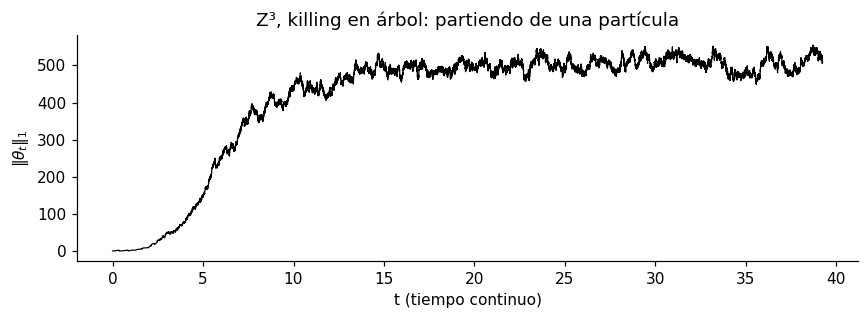

In [16]:
res_long = run_branching_process(theta0_c, n_steps=60_000, cx=cx_c, kill_mask=T_c, random_seed=SEED)
burn = res_long.n_steps // 3
print(f"eventos: {res_long.n_steps}   extinto: {res_long.extinct}   t final: {res_long.log.times[-1]:.1f}")
print(f"meseta: ‖θ‖_1 ≈ {res_long.log.l1[burn:].mean():.0f} ± {res_long.log.l1[burn:].std():.0f}"
      f"   (|E∖T| = {(~T_c).sum()} aristas disponibles)")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(res_long.log.times, res_long.log.l1, color="k", lw=0.8)
ax.set_xlabel("t (tiempo continuo)"); ax.set_ylabel(r"$\|\theta_t\|_1$")
ax.set_title("Z³, killing en árbol: partiendo de una partícula")
plt.tight_layout(); plt.show()

## 7. Condición inicial: cuadrado y cubo

Ocho escenarios que combinan tres factores:

- la dimensión: $\mathbb{Z}^2$ o $\mathbb{Z}^3$;
- la condición inicial: $+1$ en las aristas del cuadrado o cubo unitario, o un bloque de lado 3 cuyas aristas llevan $+1$ con probabilidad $\tfrac12$;
- la absorción: un árbol que evita la condición inicial, o el borde de la caja.

Con la orientación canónica estas configuraciones tienen divergencia no nula. Por eso, con absorción en el borde de la caja el proceso no puede extinguirse: la divergencia en los vértices interiores se conserva.

In [17]:
def scenario_kill_mask(cx, theta0, mode, rng):
    """Conjunto absorbente del escenario: árbol que evita el soporte de θ_0, o borde de la caja."""
    if mode == "tree":
        return spanning_tree_avoiding_mask(cx.d1, theta0 != 0, rng)
    return kill_mask_for_mode(cx, mode)


@dataclass(frozen=True)
class Scenario:
    """Un experimento: dimensión, condición inicial y condición de borde."""
    name: str
    dim: int
    initial: str   # 'unit' | 'random_block'
    mode: str      # 'tree' | 'box_boundary'


def scenario_initial_configuration(cx, scenario, rng):
    """θ_0 del escenario."""
    if scenario.initial == "unit":
        return unit_block_configuration(cx)
    return random_block_configuration(cx, side=3, p=0.5, rng=rng)


def run_scenario(scenario, box_shape, n_steps, seed):
    """Construye el complejo, θ_0 y T, y simula. Devuelve (resultado, θ_0 original)."""
    cx = build_cubical_complex(box_shape)
    rng = np.random.default_rng(seed)
    theta0 = scenario_initial_configuration(cx, scenario, rng)
    kill_mask = scenario_kill_mask(cx, theta0, scenario.mode, rng)
    return run_branching_process(theta0, n_steps, cx, kill_mask, random_seed=seed), theta0


def scenario_summary_row(scenario, result, theta0):
    """Fila de la tabla resumen."""
    lost = int(np.abs(theta0).sum() - np.abs(result.theta0).sum())
    interior = np.all((result.cx.vertices > 0) & (result.cx.vertices < 2 * np.array(result.cx.box_shape)), axis=1)
    div0 = int(np.abs(divergence(result.theta0, result.cx.d1)[interior]).sum())
    return (f"{scenario.name:30s} {np.abs(theta0).sum():5d} {lost:7d} {div0:8d} {result.n_steps:8d} "
            f"{str(result.extinct):>8s} {result.log.l1[-1]:8d} {result.log.times[-1]:9.2f}")

In [18]:
SCENARIOS = [
    Scenario("Z2 · cuadrado unitario · árbol", 2, "unit", "tree"),
    Scenario("Z2 · cuadrado unitario · borde", 2, "unit", "box_boundary"),
    Scenario("Z2 · bloque 3x3 aleat. · árbol", 2, "random_block", "tree"),
    Scenario("Z2 · bloque 3x3 aleat. · borde", 2, "random_block", "box_boundary"),
    Scenario("Z3 · cubo unitario · árbol", 3, "unit", "tree"),
    Scenario("Z3 · cubo unitario · borde", 3, "unit", "box_boundary"),
    Scenario("Z3 · bloque 3x3x3 aleat. · árbol", 3, "random_block", "tree"),
    Scenario("Z3 · bloque 3x3x3 aleat. · borde", 3, "random_block", "box_boundary"),
]
BOX = {2: (16, 16), 3: (8, 8, 8)}
MAX_STEPS = {2: 25_000, 3: 6000}
FILES = {(2, "unit"): "cuadrado", (2, "random_block"): "bloque2d", (3, "unit"): "cubo", (3, "random_block"): "bloque3d"}
MODE_LABEL = {"tree": "arbol", "box_boundary": "borde"}

scenario_results = {}
print(f"{'escenario':30s} {'‖θ0‖₁':>5s} {'perdidas':>7s} {'Σ|∂₁θ0|':>8s} {'eventos':>8s} {'extinto':>8s} "
      f"{'‖θ‖₁ fin':>8s} {'t final':>9s}")
for sc in SCENARIOS:
    result, theta0_sc = run_scenario(sc, BOX[sc.dim], n_steps=MAX_STEPS[sc.dim], seed=SEED)
    scenario_results[sc.name] = result
    print(scenario_summary_row(sc, result, theta0_sc))

escenario                      ‖θ0‖₁ perdidas  Σ|∂₁θ0|  eventos  extinto ‖θ‖₁ fin   t final


Z2 · cuadrado unitario · árbol     4       0        4    22013     True        0   2320.12


Z2 · cuadrado unitario · borde     4       0        4    25000    False      106    246.13
Z2 · bloque 3x3 aleat. · árbol     9       0       10     3417     True        0    349.68


Z2 · bloque 3x3 aleat. · borde     9       0       10    25000    False       99    174.92
Z3 · cubo unitario · árbol        12       0       12     6000    False      458      7.48


Z3 · cubo unitario · borde        12       0       12     6000    False      548      4.14
Z3 · bloque 3x3x3 aleat. · árbol    69       0       58     6000    False      458      5.60


Z3 · bloque 3x3x3 aleat. · borde    69       0       58     6000    False      616      3.45


In [19]:
scenario_videos = {}
for sc in SCENARIOS:
    path = VIDEO_DIR / f"inicial_{FILES[(sc.dim, sc.initial)]}_{MODE_LABEL[sc.mode]}.mp4"
    scenario_videos[sc.name] = render_any_dimension(scenario_results[sc.name], path, n_frames=240, title=sc.name)
    print(scenario_videos[sc.name])

videos/inicial_cuadrado_arbol.mp4


videos/inicial_cuadrado_borde.mp4


videos/inicial_bloque2d_arbol.mp4


videos/inicial_bloque2d_borde.mp4


videos/inicial_cubo_arbol.mp4


videos/inicial_cubo_borde.mp4


videos/inicial_bloque3d_arbol.mp4


videos/inicial_bloque3d_borde.mp4


#### $\mathbb{Z}^2$: cuadrado unitario (árbol / borde)

In [20]:
display(show_video(scenario_videos["Z2 · cuadrado unitario · árbol"]), show_video(scenario_videos["Z2 · cuadrado unitario · borde"]))

#### $\mathbb{Z}^2$: bloque $3\times3$ aleatorio (árbol / borde)

In [21]:
display(show_video(scenario_videos["Z2 · bloque 3x3 aleat. · árbol"]), show_video(scenario_videos["Z2 · bloque 3x3 aleat. · borde"]))

#### $\mathbb{Z}^3$: cubo unitario (árbol / borde)

In [22]:
display(show_video(scenario_videos["Z3 · cubo unitario · árbol"]), show_video(scenario_videos["Z3 · cubo unitario · borde"]))

#### $\mathbb{Z}^3$: bloque $3\times3\times3$ aleatorio (árbol / borde)

In [23]:
display(show_video(scenario_videos["Z3 · bloque 3x3x3 aleat. · árbol"]), show_video(scenario_videos["Z3 · bloque 3x3x3 aleat. · borde"]))

## 8. Probabilidad de extinción

Sea $\tau=\inf\{t:\theta_t=0\}$ el tiempo de extinción. Con absorción en un árbol generador, el paper garantiza $\tau<\infty$ casi seguramente y colas exponenciales (Teorema 2.4 y Observación 3). En esta sección estudiamos la **función de supervivencia**

$$S(t)=\mathbb{P}(\tau>t)$$

y cómo depende de la condición inicial, del número de partículas, del tamaño de la caja, del conjunto absorbente, del reloj y de la dimensión.

**Qué esperar: régimen cuasi-estacionario.** Para una cadena de Markov absorbida en un estado (aquí $\theta=0$), lo típico es que

$$S(t)\;\approx\;C(\theta_0)\,e^{-\gamma t}\qquad(t\to\infty).$$

La **tasa de decaimiento** $\gamma$ es el valor propio principal del generador restringido a los estados no absorbidos, y es una propiedad del *proceso* (de la caja, de $T$ y del reloj), **no de la condición inicial**. La condición inicial solo cambia el prefactor $C(\theta_0)$. Por lo tanto, en escala semilogarítmica las colas deberían ser **rectas paralelas**.

**Metodología**

- **Réplicas independientes y reproducibles.** Cada réplica tiene su semilla (`SeedSequence.spawn`) y las réplicas corren en paralelo con `joblib`. Los resultados no dependen del número de núcleos.
- **Árbol aleatorio por réplica (promedio *annealed*).** En cada réplica se sortea un árbol generador nuevo que evita el soporte de $\theta_0$. Así los resultados no dependen de un árbol particular.
- **Censura.** Cada réplica se corta si supera un horizonte `t_max` o un máximo de eventos. $\hat S(t)$ solo se grafica antes del primer tiempo censurado.
- **Estimador de la tasa.** Condicional a $\tau>t_0$, con $t_0$ la mediana, si la cola es exponencial entonces $\tau-t_0\sim\mathrm{Exp}(\gamma)$. El estimador de máxima verosimilitud

  $$\hat\gamma=\frac{\#\{i:\ \tau_i>t_0,\ \text{extinta}\}}{\sum_i(\tau_i-t_0)^+}$$

  incorpora las réplicas censuradas de forma natural. El intervalo de confianza al 95 % se obtiene por *bootstrap*.
- **Tiempo.** Por defecto $\tau$ se mide en tiempo continuo (Gillespie); en el experimento del reloj también se mide en número de eventos.

In [24]:
def replica_seeds(master_seed, n):
    """Semillas independientes y reproducibles para n réplicas."""
    return np.random.SeedSequence(master_seed).spawn(n)


def extinction_replica(cx, init_fn, kill_fn, seed, max_steps, t_max, clock):
    """Una réplica: (τ, n.º de eventos, ¿extinta?, máx ‖θ_t‖_1, ‖θ_0‖_1 efectivo).

    `init_fn(cx, rng)` construye θ_0 y `kill_fn(cx, θ_0, rng)` construye T, que se sortea en cada réplica."""
    rng = np.random.default_rng(seed)
    theta0 = init_fn(cx, rng)
    kill_mask = kill_fn(cx, theta0, rng)
    r = run_branching_process(theta0, max_steps, cx, kill_mask, random_seed=rng, clock=clock, t_max=t_max)
    return r.log.times[-1], r.n_steps, r.extinct, r.log.l1.max(), r.log.l1[0]


def extinction_chunk(box_shape, init_fn, kill_fn, seeds, max_steps, t_max, clock):
    """Un bloque de réplicas en un mismo proceso: el complejo se construye una sola vez por bloque."""
    cx = build_cubical_complex(box_shape)
    return [extinction_replica(cx, init_fn, kill_fn, s, max_steps, t_max, clock) for s in seeds]


@dataclass(frozen=True)
class ExtinctionSample:
    """Resultados de R réplicas independientes de un mismo experimento."""
    label: str
    tau: np.ndarray      # tiempo de extinción (o de censura si no se extinguió)
    events: np.ndarray   # número de eventos
    extinct: np.ndarray  # ¿se extinguió?
    peak: np.ndarray     # máximo de ‖θ_t‖_1
    mass0: np.ndarray    # ‖θ_0‖_1 después de quitar T y de las cancelaciones iniciales

    def values(self, scale="time"):
        """τ en tiempo continuo ('time') o en número de eventos ('events')."""
        return self.tau if scale == "time" else self.events.astype(float)


def extinction_sample(label, box_shape, init_fn, kill_fn, n_replicas, master_seed=SEED,
                      max_steps=2_000_000, t_max=np.inf, clock="generator", n_jobs=-1, n_chunks=40):
    """Corre n_replicas réplicas, repartidas en bloques que se ejecutan en paralelo (joblib).

    Cada réplica usa su propia semilla, así que el resultado no depende de n_jobs ni de n_chunks."""
    seeds = replica_seeds(master_seed, n_replicas)
    chunks = [list(c) for c in np.array_split(np.array(seeds, dtype=object), min(n_chunks, n_replicas))]
    blocks = Parallel(n_jobs=n_jobs)(
        delayed(extinction_chunk)(tuple(box_shape), init_fn, kill_fn, c, max_steps, t_max, clock) for c in chunks)
    a = np.array([row for b in blocks for row in b], dtype=float)
    return ExtinctionSample(label, a[:, 0], a[:, 1].astype(np.int64), a[:, 2].astype(bool),
                            a[:, 3].astype(np.int64), a[:, 4].astype(np.int64))

In [25]:
def censoring_level(values, extinct):
    """Menor valor censurado: Ŝ es exacta solo antes de este punto."""
    return values[~extinct].min() if (~extinct).any() else np.inf


def survival_function(values, extinct, grid):
    """Ŝ(t) = P̂(τ > t) sobre `grid` (NaN desde el nivel de censura en adelante)."""
    S = (values[:, None] > grid[None, :]).mean(axis=0)
    S[grid >= censoring_level(values, extinct)] = np.nan
    return S


def tail_rate_mle(values, extinct, q0=0.5):
    """γ̂ de la cola P(τ > t) ≈ C e^{-γt}: MLE de τ - t_0 ~ Exp(γ) condicional a τ > t_0 (t_0 = cuantil q0)."""
    t0 = np.quantile(values, q0)
    if t0 >= censoring_level(values, extinct):  # el cuantil cae en la zona censurada: no estimable
        return np.nan
    beyond = values > t0
    exposure = (values[beyond] - t0).sum()
    return np.sum(extinct[beyond]) / exposure if exposure > 0 else np.nan


def bootstrap_tail_rate(values, extinct, rng, n_boot=300, q0=0.5):
    """(γ̂, extremo inferior, extremo superior) con intervalo bootstrap percentil al 95 %."""
    g = tail_rate_mle(values, extinct, q0)
    if np.isnan(g):
        return g, np.nan, np.nan
    idx = rng.integers(len(values), size=(n_boot, len(values)))
    boots = np.array([tail_rate_mle(values[i], extinct[i], q0) for i in idx])
    return (g, *np.nanpercentile(boots, [2.5, 97.5]))


def independent_max_benchmark(values, n, rng, n_draws=4000):
    """E[máx de n copias independientes de τ], remuestreando una muestra de τ con 1 partícula."""
    return rng.choice(values, size=(n_draws, n)).max(axis=1).mean()


def summarize(sample, rng, scale="time"):
    """Resumen estadístico de una muestra."""
    v = sample.values(scale)
    g, lo, hi = bootstrap_tail_rate(v, sample.extinct, rng)
    return dict(label=sample.label, R=len(v), p_ext=sample.extinct.mean(), mean=v.mean(), median=np.median(v),
                gamma=g, gamma_lo=lo, gamma_hi=hi, gamma80=tail_rate_mle(v, sample.extinct, 0.8),
                gamma95=tail_rate_mle(v, sample.extinct, 0.95), peak=sample.peak.mean(), mass0=sample.mass0.mean())


def fmt_rate(x, width=8):
    """Formatea una tasa ('n/d' si no es estimable por censura)."""
    return f"{'n/d':>{width}s}" if np.isnan(x) else f"{x:{width}.4f}"


def print_summary(samples, scale="time", seed=0):
    """Tabla resumen. γ̂ se estima más allá de la mediana (con IC 95 %), y también más allá de los
    cuantiles 0.8 y 0.95: si la cola es exponencial, las tres estimaciones coinciden.
    Si hay censura, la media es una cota inferior (≥)."""
    rng = np.random.default_rng(seed)
    rows = [summarize(s, rng, scale) for s in samples]
    unit = "t" if scale == "time" else "eventos"
    print(f"{'experimento':30s} {'R':>5s} {'‖θ0‖₁':>6s} {'P(ext)':>6s} {'E[τ]':>9s} {'mediana':>8s} "
          f"{'γ̂₅₀ (IC 95%)':>27s} {'γ̂₈₀':>8s} {'γ̂₉₅':>8s} {'máx‖θ‖₁':>8s}   [τ en {unit}]")
    for r in rows:
        mean = ("≥" if r["p_ext"] < 1 else " ") + f"{r['mean']:8.1f}"
        ci = "" if np.isnan(r["gamma"]) else f"({r['gamma_lo']:.4f}–{r['gamma_hi']:.4f})"
        print(f"{r['label']:30s} {r['R']:5d} {r['mass0']:6.1f} {r['p_ext']:6.3f} {mean:>9s} {r['median']:8.1f} "
              f"{fmt_rate(r['gamma'])} {ci:>18s} {fmt_rate(r['gamma80'])} {fmt_rate(r['gamma95'])} {r['peak']:8.1f}")
    return rows

In [26]:
def plot_survival(ax, samples, scale="time", show_fit=True, n_grid=400, quantile_max=0.998):
    """Ŝ(t) en escala semilogarítmica, con la recta de la cola ajustada (desde la mediana)."""
    vmax = max(np.quantile(s.values(scale), quantile_max) for s in samples)
    grid = np.linspace(0, vmax, n_grid)
    for s in samples:
        v = s.values(scale)
        line, = ax.semilogy(grid, survival_function(v, s.extinct, grid), lw=1.6, label=s.label)
        if show_fit:
            t0, g = np.median(v), tail_rate_mle(v, s.extinct)
            tt = grid[grid >= t0]
            ax.semilogy(tt, np.mean(v > t0) * np.exp(-g * (tt - t0)), ls="--", lw=0.9, color=line.get_color())
    ax.set_ylim(0.5 / max(len(s.tau) for s in samples), 1.1)
    ax.set_xlabel("t" if scale == "time" else "eventos")
    ax.set_ylabel(r"$\hat{\mathbb{P}}(\tau>t)$")
    ax.legend(frameon=False, fontsize=8)


def plot_conditional_tails(ax, samples, scale="time", n_grid=300):
    """Ŝ(t_0 + s) / Ŝ(t_0) con t_0 = mediana: si la tasa γ es común, las curvas colapsan en una recta."""
    for s in samples:
        v = s.values(scale)
        t0 = np.median(v)
        tail = v[v > t0] - t0
        grid = np.linspace(0, np.quantile(tail, 0.99), n_grid)
        ax.semilogy(grid, survival_function(tail, s.extinct[v > t0], grid), lw=1.4, label=s.label)
    ax.set_xlabel(r"$s = t - t_{0}$ ($t_0$ = mediana)")
    ax.set_ylabel(r"$\hat{\mathbb{P}}(\tau>t_0+s\mid\tau>t_0)$")


def plot_rates(ax, rows):
    """γ̂ con su intervalo de confianza, una barra por experimento."""
    y = np.arange(len(rows))
    g = np.array([r["gamma"] for r in rows])
    err = np.array([[r["gamma"] - r["gamma_lo"], r["gamma_hi"] - r["gamma"]] for r in rows]).T
    ax.errorbar(g, y, xerr=err, fmt="o", color="k", capsize=3)
    ax.set_yticks(y, [r["label"] for r in rows], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel(r"tasa de la cola $\hat\gamma$")

In [27]:
def center_edge_index(cx):
    """Arista más cercana al centro de la caja."""
    return int(np.argmin(np.abs(cx.edges - np.array(cx.box_shape)).sum(axis=1)))


def init_single_particle(cx, rng):
    """Una partícula +1 en la arista central."""
    theta = np.zeros(len(cx.edges), np.int64)
    theta[center_edge_index(cx)] = 1
    return theta


def init_random_particles(cx, rng, n, signed=True, radius=2.0, forbidden=None):
    """n partículas (signo ±1 uniforme o todas +1) en aristas uniformes a distancia ℓ∞ ≤ radius del centro,
    excluyendo las aristas marcadas en `forbidden` (por ejemplo, un árbol fijo)."""
    support = central_edges(cx, radius)
    if forbidden is not None:
        support = np.setdiff1d(support, np.flatnonzero(forbidden))
    signs = rng.choice([-1, 1], size=n) if signed else np.ones(n, np.int64)
    return np.bincount(rng.choice(support, size=n), weights=signs, minlength=len(cx.edges)).astype(np.int64)


def init_oriented_square(cx, rng):
    """Lazo θ_0 = ∂f de la cara central (orientado antihorario, divergencia nula). Solo d = 2."""
    c = np.array(cx.box_shape) // 2 - 0.5
    return loop_configuration(cx, c, c)


def init_unit_square(cx, rng):
    """+1 en las aristas del cuadrado (o cubo) unitario central, con orientación canónica."""
    return unit_block_configuration(cx)


def init_random_block(cx, rng, side=3, p=0.5):
    """+1 en cada arista del bloque central de lado `side` con probabilidad p."""
    return random_block_configuration(cx, side, p, rng)


def kill_tree(cx, theta0, rng):
    """Árbol generador aleatorio que evita (en lo posible) el soporte de θ_0."""
    return spanning_tree_avoiding_mask(cx.d1, theta0 != 0, rng)


def kill_tree_plus(cx, theta0, rng, q):
    """Árbol generador ∪ cada arista restante (fuera del soporte de θ_0) con probabilidad q."""
    T = kill_tree(cx, theta0, rng)
    return T | (~T & (theta0 == 0) & (rng.random(len(T)) < q))


def kill_fixed(cx, theta0, rng, mask):
    """Conjunto absorbente fijo, igual en todas las réplicas (promedio 'quenched')."""
    return mask


def kill_box(cx, theta0, rng):
    """Aristas del borde de la caja."""
    return box_boundary_edge_mask(cx)

### 8.1 Efecto de la condición inicial

Caja $10\times10$, absorción en un árbol y $R=2000$ réplicas por condición inicial:

- una partícula;
- el lazo $\partial f$ de una cara (cuadrado orientado, divergencia nula);
- el cuadrado con $+1$ en sus 4 aristas (orientación canónica);
- un bloque $3\times3$ con aristas ocupadas con probabilidad $\tfrac12$;
- 10 partículas aleatorias con signo $\pm1$;
- 10 partículas aleatorias $+1$.

**Paneles:**

- **izquierda:** $\hat S(t)$, con la recta ajustada a la cola en línea discontinua;
- **centro:** la cola condicionada $\hat S(t_0+s)/\hat S(t_0)$; si $\gamma$ no depende de $\theta_0$, las curvas deberían colapsar;
- **derecha:** $\hat\gamma$ con su intervalo de confianza al 95 %.

experimento                        R  ‖θ0‖₁ P(ext)      E[τ]  mediana               γ̂₅₀ (IC 95%)     γ̂₈₀     γ̂₉₅  máx‖θ‖₁   [τ en t]
1 partícula                     2000    1.0  1.000      91.8     14.7   0.0061    (0.0054–0.0067)   0.0039   0.0030      4.9
lazo ∂f (cuadrado orientado)    2000    4.0  1.000      12.3      0.3   0.0412    (0.0307–0.0556)   0.0177   0.0067      4.9
cuadrado +1 (canónico)          2000    4.0  1.000     238.9    112.8   0.0031    (0.0029–0.0033)   0.0026   0.0020      9.7
bloque 3×3 aleatorio            2000   11.7  1.000     498.0    358.5   0.0021    (0.0020–0.0023)   0.0022   0.0022     16.0
10 partículas ±1                2000    8.9  1.000     334.3    190.6   0.0025    (0.0024–0.0027)   0.0023   0.0021     13.0
10 partículas +1                2000   10.0  1.000     402.4    270.1   0.0024    (0.0023–0.0026)   0.0024   0.0024     14.6


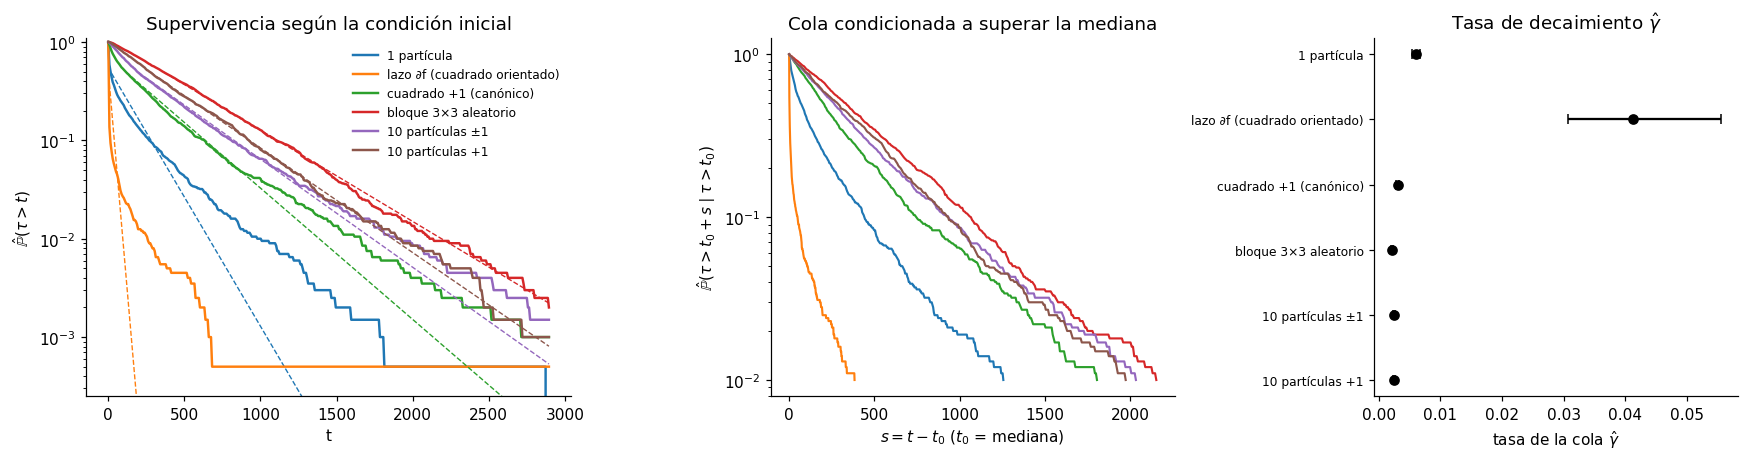

In [28]:
L_REF = (10, 10)
R_REF = 2000
INITIAL_CONDITIONS = {
    "1 partícula": init_single_particle,
    "lazo ∂f (cuadrado orientado)": init_oriented_square,
    "cuadrado +1 (canónico)": init_unit_square,
    "bloque 3×3 aleatorio": partial(init_random_block, side=3, p=0.5),
    "10 partículas ±1": partial(init_random_particles, n=10, signed=True),
    "10 partículas +1": partial(init_random_particles, n=10, signed=False),
}
samples_ic = [extinction_sample(name, L_REF, f, kill_tree, R_REF, master_seed=SEED + k)
              for k, (name, f) in enumerate(INITIAL_CONDITIONS.items())]
rows_ic = print_summary(samples_ic)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), gridspec_kw={"width_ratios": [1.2, 1, 0.9]})
plot_survival(axes[0], samples_ic)
axes[0].set_title("Supervivencia según la condición inicial")
plot_conditional_tails(axes[1], samples_ic)
axes[1].set_title("Cola condicionada a superar la mediana")
plot_rates(axes[2], rows_ic)
axes[2].set_title(r"Tasa de decaimiento $\hat\gamma$")
plt.tight_layout(); plt.show()

### 8.2 Árbol fijo: la tasa es propia del árbol, no de la condición inicial

En 8.1 las colas **no son rectas** en escala semilogarítmica: son convexas, con una caída rápida al principio y más lenta después. Además la tasa efectiva cambia con la condición inicial, lo que contradice a primera vista la hipótesis cuasi-estacionaria. La explicación es que en 8.1 el árbol se sortea en cada réplica, y entonces

$$S(t)=\mathbb{E}_T\big[S_T(t)\big]\approx\mathbb{E}_T\big[C_T(\theta_0)\,e^{-\gamma(T)t}\big]$$

es una **mezcla de exponenciales** con tasas $\gamma(T)$ distintas. Una mezcla así tiene cola convexa, y su cola profunda la dominan los árboles "lentos".

Para comprobarlo **fijamos el árbol** (promedio *quenched*) y repetimos el experimento con tres árboles distintos. Los tres evitan la arista central y el cuadrado unitario, y las partículas aleatorias se colocan fuera del árbol. Si la teoría es correcta, para cada árbol las colas deberían ser paralelas, con una tasa $\gamma(T)$ común a todas las condiciones iniciales; las columnas $\hat\gamma_{80}$ y $\hat\gamma_{95}$ deberían coincidir. Lo que debería cambiar es la tasa **entre** árboles.

Árbol fijo 0   (c'(T) = 0.00369)


experimento                        R  ‖θ0‖₁ P(ext)      E[τ]  mediana               γ̂₅₀ (IC 95%)     γ̂₈₀     γ̂₉₅  máx‖θ‖₁   [τ en t]
1 partícula                     2000    1.0  1.000     269.1    174.1   0.0036    (0.0034–0.0038)   0.0034   0.0038      9.0
lazo ∂f                         2000    4.0  1.000      12.3      0.3   0.0414    (0.0330–0.0554)   0.0177   0.0056      4.9
cuadrado +1                     2000    4.0  1.000     430.3    354.4   0.0034    (0.0032–0.0036)   0.0036   0.0041     11.3
10 partículas ±1                2000    8.3  1.000     310.5    228.6   0.0033    (0.0031–0.0035)   0.0039   0.0039     12.9
10 partículas +1                2000   10.0  1.000     429.5    358.7   0.0031    (0.0030–0.0033)   0.0037   0.0034     14.9

Árbol fijo 1   (c'(T) = 0.00418)


experimento                        R  ‖θ0‖₁ P(ext)      E[τ]  mediana               γ̂₅₀ (IC 95%)     γ̂₈₀     γ̂₉₅  máx‖θ‖₁   [τ en t]
1 partícula                     2000    1.0  1.000      98.9     33.8   0.0068    (0.0063–0.0074)   0.0046   0.0047      7.4
lazo ∂f                         2000    4.0  1.000      12.0      0.3   0.0423    (0.0344–0.0563)   0.0179   0.0063      5.1
cuadrado +1                     2000    4.0  1.000     313.5    246.5   0.0040    (0.0038–0.0043)   0.0042   0.0047     12.0
10 partículas ±1                2000    8.2  1.000     243.1    161.6   0.0038    (0.0036–0.0041)   0.0039   0.0048     12.5
10 partículas +1                2000   10.0  1.000     337.9    275.7   0.0037    (0.0035–0.0039)   0.0040   0.0041     14.7

Árbol fijo 2   (c'(T) = 0.01046)


experimento                        R  ‖θ0‖₁ P(ext)      E[τ]  mediana               γ̂₅₀ (IC 95%)     γ̂₈₀     γ̂₉₅  máx‖θ‖₁   [τ en t]
1 partícula                     2000    1.0  1.000      17.3      3.0   0.0330    (0.0289–0.0381)   0.0160   0.0092      3.8
lazo ∂f                         2000    4.0  1.000       8.7      0.3   0.0589    (0.0491–0.0715)   0.0259   0.0105      4.8
cuadrado +1                     2000    4.0  1.000      53.4     19.2   0.0125    (0.0115–0.0135)   0.0105   0.0106      7.8
10 partículas ±1                2000    8.1  1.000     101.9     75.1   0.0107    (0.0101–0.0114)   0.0108   0.0117     11.2
10 partículas +1                2000   10.0  1.000     116.8     92.4   0.0103    (0.0097–0.0109)   0.0110   0.0101     13.2



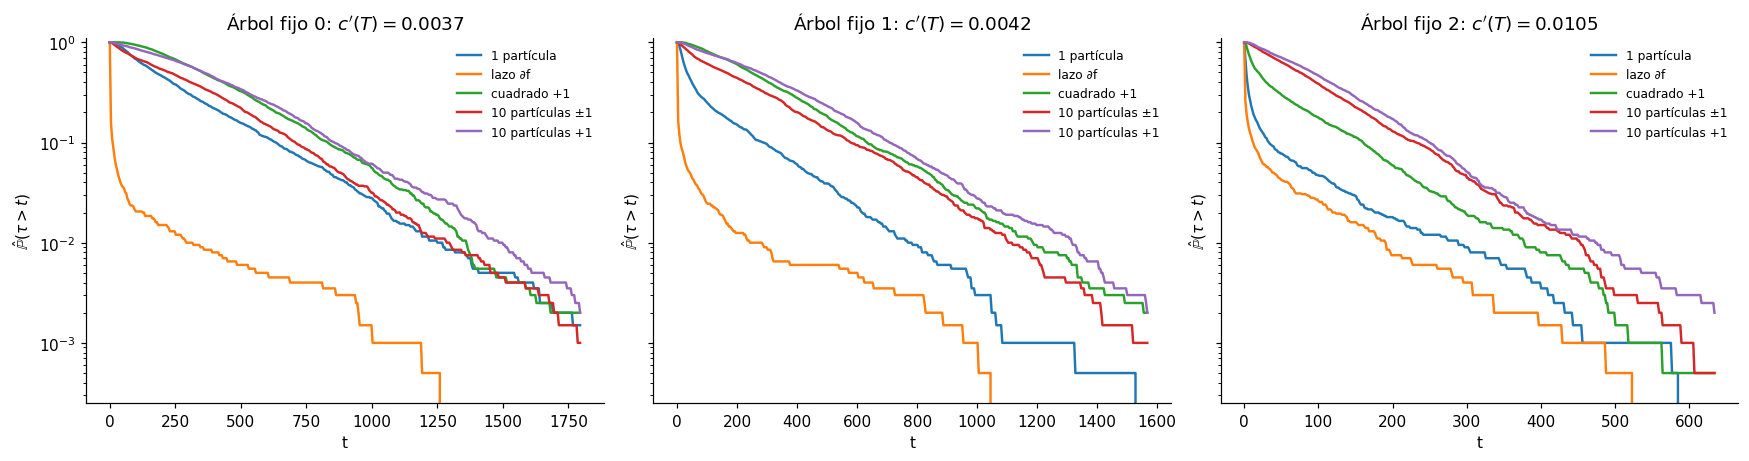

In [29]:
cx_q = build_cubical_complex(L_REF)
avoid_q = (init_single_particle(cx_q, None) != 0) | (init_unit_square(cx_q, None) != 0)
FIXED_TREES = [spanning_tree_avoiding_mask(cx_q.d1, avoid_q, np.random.default_rng(100 + k)) for k in range(3)]


def quenched_initial_conditions(T0):
    """Condiciones iniciales compatibles con el árbol fijo T0."""
    return {
        "1 partícula": init_single_particle,
        "lazo ∂f": init_oriented_square,
        "cuadrado +1": init_unit_square,
        "10 partículas ±1": partial(init_random_particles, n=10, signed=True, forbidden=T0),
        "10 partículas +1": partial(init_random_particles, n=10, signed=False, forbidden=T0),
    }


samples_q = []
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharey=True)
for k, T0 in enumerate(FIXED_TREES):
    c_T0 = poincare_constant(cx_q.d2, T0)[0]
    print(f"Árbol fijo {k}   (c'(T) = {c_T0:.5f})")
    samples_k = [extinction_sample(name, L_REF, f, partial(kill_fixed, mask=T0), R_REF, master_seed=SEED + 600 + 10 * k + j)
                 for j, (name, f) in enumerate(quenched_initial_conditions(T0).items())]
    print_summary(samples_k)
    print()
    samples_q.append(samples_k)
    plot_survival(axes[k], samples_k, show_fit=False)
    axes[k].set_title(fr"Árbol fijo {k}: $c'(T)={c_T0:.4f}$")
plt.tight_layout(); plt.show()

### 8.3 Distribución de $\gamma(T)$ entre árboles y constante de Poincaré

Sorteamos 40 árboles generadores. Para cada uno estimamos $\gamma(T)$ más allá del cuantil 0.8, con 600 réplicas que parten del cuadrado $+1$, y calculamos su constante de Poincaré $c'(T)$, el menor valor propio de $\Delta^\uparrow$ restringido a $E\setminus T$.

γ(T): mediana 0.0051, rango [0.0016, 0.0138] (máx/mín = 8.6)
c'(T): rango [0.00171, 0.01127]     corr(log c', log γ) = 0.95     γ ∝ (c')^1.07


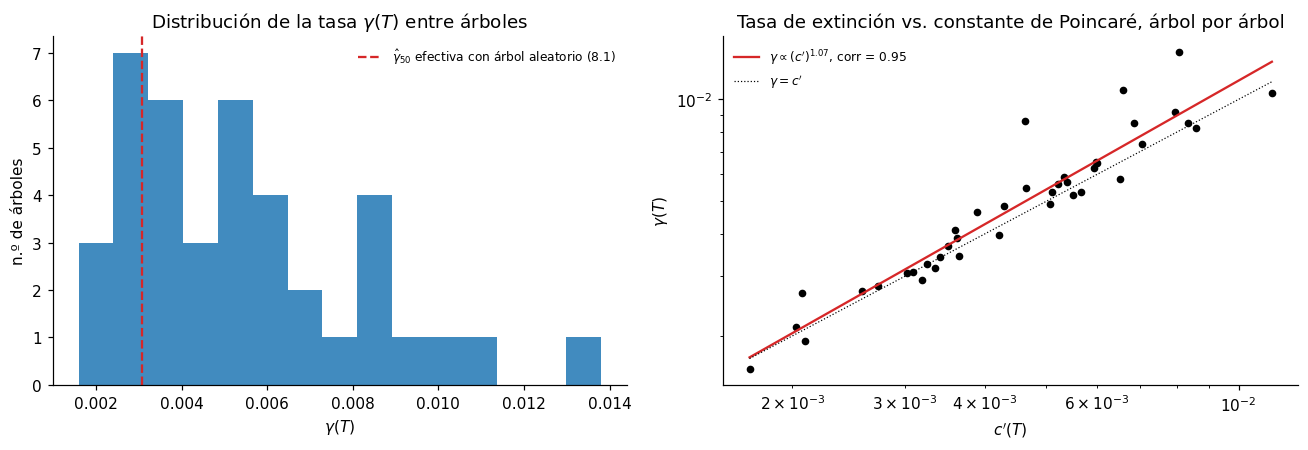

In [30]:
N_TREES, R_TREE = 40, 600
trees = [spanning_tree_avoiding_mask(cx_q.d1, avoid_q, np.random.default_rng(SEED + 700 + k)) for k in range(N_TREES)]
gamma_T = []
for k, T0 in enumerate(trees):
    s = extinction_sample(f"árbol {k}", L_REF, init_unit_square, partial(kill_fixed, mask=T0), R_TREE,
                          master_seed=SEED + 800 + k)
    gamma_T.append(tail_rate_mle(s.tau, s.extinct, q0=0.8))
gamma_T = np.array(gamma_T)
c_T = np.array([poincare_constant(cx_q.d2, T0)[0] for T0 in trees])
slope_T, icpt_T = np.polyfit(np.log(c_T), np.log(gamma_T), 1)
corr_T = np.corrcoef(np.log(c_T), np.log(gamma_T))[0, 1]
print(f"γ(T): mediana {np.median(gamma_T):.4f}, rango [{gamma_T.min():.4f}, {gamma_T.max():.4f}] "
      f"(máx/mín = {gamma_T.max() / gamma_T.min():.1f})")
print(f"c'(T): rango [{c_T.min():.5f}, {c_T.max():.5f}]     corr(log c', log γ) = {corr_T:.2f}     γ ∝ (c')^{slope_T:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(gamma_T, bins=15, color="C0", alpha=0.85)
axes[0].axvline(rows_ic[2]["gamma"], color="C3", ls="--", label=r"$\hat\gamma_{50}$ efectiva con árbol aleatorio (8.1)")
axes[0].set_xlabel(r"$\gamma(T)$"); axes[0].set_ylabel("n.º de árboles"); axes[0].legend(frameon=False, fontsize=8)
axes[0].set_title(r"Distribución de la tasa $\gamma(T)$ entre árboles")
axes[1].loglog(c_T, gamma_T, "o", color="k", ms=4)
cc = np.geomspace(c_T.min(), c_T.max(), 50)
axes[1].loglog(cc, np.exp(icpt_T) * cc ** slope_T, "C3-", label=fr"$\gamma\propto (c')^{{{slope_T:.2f}}}$, corr = {corr_T:.2f}")
axes[1].loglog(cc, cc, "k:", lw=0.8, label=r"$\gamma = c'$")
axes[1].set_xlabel(r"$c'(T)$"); axes[1].set_ylabel(r"$\gamma(T)$"); axes[1].legend(frameon=False, fontsize=8)
axes[1].set_title("Tasa de extinción vs. constante de Poincaré, árbol por árbol")
plt.tight_layout(); plt.show()

### 8.4 Número de partículas iniciales

Ahora ponemos $N\in\{1,2,4,\dots,64\}$ partículas al azar cerca del centro, con dos variantes de signo: todas $+1$, o signo $\pm1$ aleatorio, en cuyo caso parte de ellas se cancela de entrada. Comparamos $\mathbb{E}[\tau_N]$ con una **referencia de partículas independientes**: el máximo de $N$ copias independientes del tiempo de extinción de una partícula, estimado remuestreando la muestra de una partícula de 8.1. Si la cola es exponencial con tasa $\gamma$, esa referencia crece como $\log N/\gamma$. Lo que se aparte de ella mide el efecto de la interacción: aniquilación y árbol común.

La tasa $\hat\gamma_{50}$ que se reporta es *efectiva*, es decir, de una mezcla sobre árboles (8.2). Si baja al aumentar $N$, eso indica que con más masa inicial la supervivencia queda dominada por los árboles más lentos.

experimento                        R  ‖θ0‖₁ P(ext)      E[τ]  mediana               γ̂₅₀ (IC 95%)     γ̂₈₀     γ̂₉₅  máx‖θ‖₁   [τ en t]
N=1 (+1)                        1000    1.0  1.000      95.5     12.5   0.0057    (0.0050–0.0067)   0.0035   0.0025      4.6
N=2 (+1)                        1000    2.0  1.000     152.8     50.7   0.0042    (0.0036–0.0047)   0.0031   0.0020      6.7
N=4 (+1)                        1000    4.0  1.000     214.7     95.6   0.0034    (0.0030–0.0037)   0.0027   0.0024      9.2
N=8 (+1)                        1000    8.0  1.000     349.4    203.1   0.0025    (0.0023–0.0027)   0.0026   0.0023     13.0
N=16 (+1)                       1000   15.9  1.000     582.8    445.1   0.0020    (0.0018–0.0022)   0.0019   0.0019     19.5
N=32 (+1)                       1000   30.6  1.000     849.4    742.6   0.0019    (0.0017–0.0020)   0.0021   0.0018     32.8
N=64 (+1)                       1000   55.0  1.000    1096.6    971.4   0.0016    (0.0015–0.0018)   0.0015   0.001

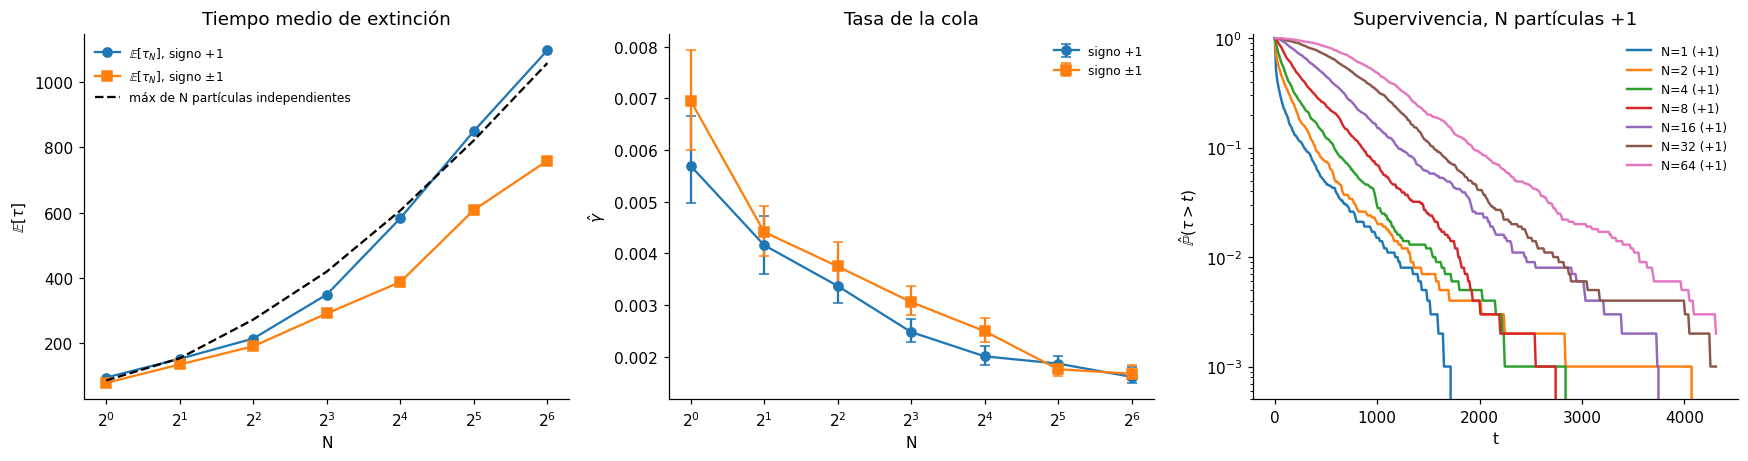

In [31]:
N_VALUES = [1, 2, 4, 8, 16, 32, 64]
R_N = 1000
samples_N = {
    sign: [extinction_sample(f"N={n} ({sign})", L_REF,
                             partial(init_random_particles, n=n, signed=(sign == "±1")),
                             kill_tree, R_N, master_seed=SEED + 100 + n + (1000 if sign == "±1" else 0))
           for n in N_VALUES]
    for sign in ["+1", "±1"]
}
rows_N = {sign: print_summary(s) for sign, s in samples_N.items()}

rng_bench = np.random.default_rng(1)
tau_single = samples_ic[0].tau
benchmark = [independent_max_benchmark(tau_single, n, rng_bench) for n in N_VALUES]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for sign, marker in [("+1", "o"), ("±1", "s")]:
    axes[0].plot(N_VALUES, [r["mean"] for r in rows_N[sign]], marker=marker, label=fr"$\mathbb{{E}}[\tau_N]$, signo {sign}")
axes[0].plot(N_VALUES, benchmark, "k--", label="máx de N partículas independientes")
axes[0].set_xscale("log", base=2); axes[0].set_xlabel("N"); axes[0].set_ylabel(r"$\mathbb{E}[\tau]$")
axes[0].legend(frameon=False, fontsize=8); axes[0].set_title("Tiempo medio de extinción")

for sign, marker in [("+1", "o"), ("±1", "s")]:
    g = np.array([[r["gamma"], r["gamma_lo"], r["gamma_hi"]] for r in rows_N[sign]])
    axes[1].errorbar(N_VALUES, g[:, 0], yerr=[g[:, 0] - g[:, 1], g[:, 2] - g[:, 0]], marker=marker, capsize=3, label=f"signo {sign}")
axes[1].set_xscale("log", base=2); axes[1].set_xlabel("N"); axes[1].set_ylabel(r"$\hat\gamma$")
axes[1].legend(frameon=False, fontsize=8); axes[1].set_title("Tasa de la cola")

plot_survival(axes[2], samples_N["+1"], show_fit=False)
axes[2].set_title("Supervivencia, N partículas +1")
plt.tight_layout(); plt.show()

### 8.5 Tamaño de la caja y constante de Poincaré

Usamos una partícula inicial y cajas $L\times L$ con $L\in\{4,\dots,20\}$. El paper relaciona la extinción con la constante de Poincaré $c'$ del Lema 2.3, que es el menor valor propio de $\Delta^\uparrow$ restringido a $E\setminus T$. Para cada $L$ promediamos $c'$ sobre 5 árboles aleatorios y comparamos con la tasa efectiva $\hat\gamma_{50}$ (árbol aleatorio por réplica).

experimento                        R  ‖θ0‖₁ P(ext)      E[τ]  mediana               γ̂₅₀ (IC 95%)     γ̂₈₀     γ̂₉₅  máx‖θ‖₁   [τ en t]
L=4                             1000    1.0  1.000      12.6      3.9   0.0499    (0.0449–0.0569)   0.0369   0.0317      2.2
L=6                             1000    1.0  1.000      27.6      6.5   0.0214    (0.0184–0.0242)   0.0147   0.0113      3.1
L=8                             1000    1.0  1.000      52.1     10.3   0.0110    (0.0095–0.0126)   0.0073   0.0061      4.0
L=10                            1000    1.0  1.000      88.8     13.7   0.0062    (0.0056–0.0071)   0.0040   0.0035      4.8
L=12                            1000    1.0  1.000     150.6     21.6   0.0036    (0.0032–0.0042)   0.0024   0.0016      5.7
L=16                            1000    1.0  1.000     221.1     15.7   0.0024    (0.0020–0.0028)   0.0013   0.0011      6.2
L=20                            1000    1.0  1.000     416.2     17.5   0.0012    (0.0011–0.0015)   0.0007   0.000

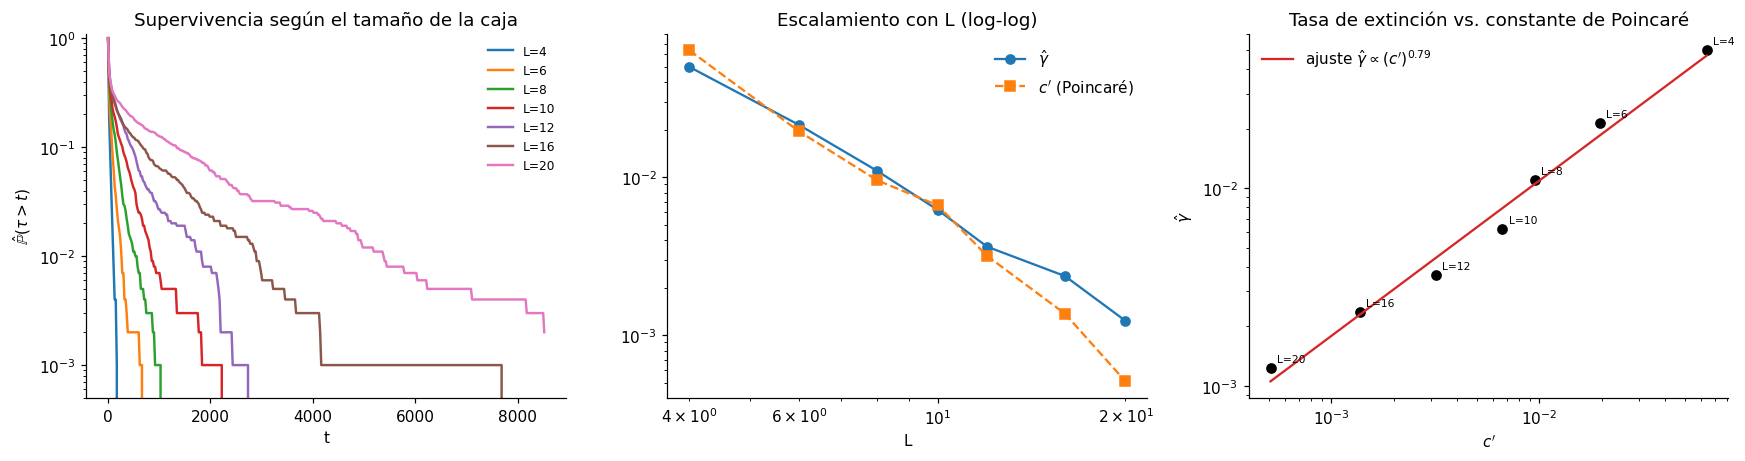

In [32]:
L_VALUES = [4, 6, 8, 10, 12, 16, 20]
R_L = 1000
samples_L = [extinction_sample(f"L={L}", (L, L), init_single_particle, kill_tree, R_L, master_seed=SEED + 200 + L)
             for L in L_VALUES]
rows_L = print_summary(samples_L)


def mean_poincare_constant(L, n_trees, rng):
    """c'(L) promediado sobre árboles aleatorios que evitan la arista central."""
    cx = build_cubical_complex((L, L))
    theta0 = init_single_particle(cx, rng)
    return np.mean([poincare_constant(cx.d2, kill_tree(cx, theta0, rng))[0] for _ in range(n_trees)])


rng_p = np.random.default_rng(SEED)
c_poincare = np.array([mean_poincare_constant(L, 5, rng_p) for L in L_VALUES])
gammas_L = np.array([r["gamma"] for r in rows_L])
slope_L = np.polyfit(np.log(L_VALUES), np.log(gammas_L), 1)[0]
slope_c = np.polyfit(np.log(c_poincare), np.log(gammas_L), 1)[0]
slope_cL = np.polyfit(np.log(L_VALUES), np.log(c_poincare), 1)[0]
print(f"\nγ̂ ∝ L^{slope_L:.2f}     c' ∝ L^{slope_cL:.2f}     γ̂ ∝ (c')^{slope_c:.2f}")
for L, c, g in zip(L_VALUES, c_poincare, gammas_L):
    print(f"L={L:2d}   c' = {c:.5f}   γ̂ = {g:.5f}   γ̂/c' = {g / c:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
plot_survival(axes[0], samples_L, show_fit=False)
axes[0].set_title("Supervivencia según el tamaño de la caja")
axes[1].loglog(L_VALUES, gammas_L, "o-", label=r"$\hat\gamma$")
axes[1].loglog(L_VALUES, c_poincare, "s--", label=r"$c'$ (Poincaré)")
axes[1].set_xlabel("L"); axes[1].legend(frameon=False); axes[1].set_title("Escalamiento con L (log-log)")
axes[2].loglog(c_poincare, gammas_L, "o", color="k")
cc = np.geomspace(c_poincare.min(), c_poincare.max(), 50)
axes[2].loglog(cc, np.exp(np.polyval(np.polyfit(np.log(c_poincare), np.log(gammas_L), 1), np.log(cc))), "C3-",
               label=fr"ajuste $\hat\gamma\propto (c')^{{{slope_c:.2f}}}$")
for L, c, g in zip(L_VALUES, c_poincare, gammas_L):
    axes[2].annotate(f"L={L}", (c, g), textcoords="offset points", xytext=(4, 4), fontsize=7)
axes[2].set_xlabel(r"$c'$"); axes[2].set_ylabel(r"$\hat\gamma$"); axes[2].legend(frameon=False)
axes[2].set_title("Tasa de extinción vs. constante de Poincaré")
plt.tight_layout(); plt.show()

### 8.6 Conjunto absorbente

Tomamos como condición inicial el lazo $\partial f$, que tiene divergencia nula, para que la absorción en el borde de la caja también permita extinguirse. Comparamos:

- el árbol generador solo;
- el árbol más una fracción $q$ de las aristas restantes, sorteadas al azar;
- el borde de la caja.

En el eje horizontal se muestra la fracción de aristas absorbentes $|T|/|E|$.

experimento                        R  ‖θ0‖₁ P(ext)      E[τ]  mediana               γ̂₅₀ (IC 95%)     γ̂₈₀     γ̂₉₅  máx‖θ‖₁   [τ en t]
árbol + 0 % extra               2000    4.0  1.000      14.3      0.3   0.0354    (0.0269–0.0480)   0.0148   0.0047      4.8
árbol + 10 % extra              2000    4.0  1.000       8.5      0.3   0.0603    (0.0462–0.0797)   0.0265   0.0092      4.6
árbol + 25 % extra              2000    4.0  1.000       4.1      0.3   0.1267    (0.1027–0.1609)   0.0620   0.0260      4.4
árbol + 50 % extra              2000    4.0  1.000       2.1      0.3   0.2623    (0.2383–0.2923)   0.1762   0.1139      4.1
borde de la caja                2000    4.0  1.000       2.5      0.3   0.2175    (0.1796–0.2666)   0.1006   0.0386      9.5


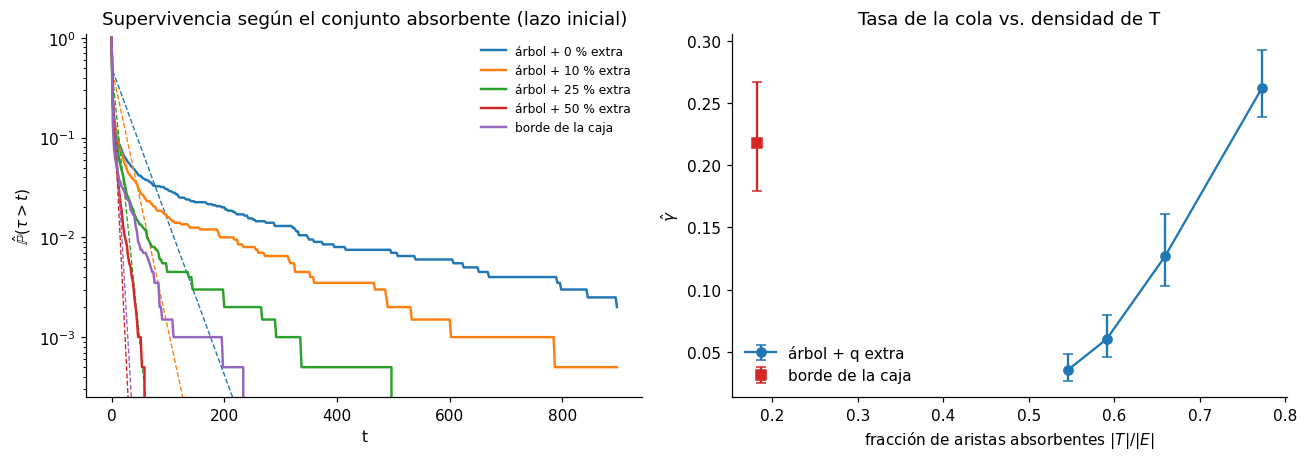

In [33]:
Q_VALUES = [0.0, 0.1, 0.25, 0.5]
KILL_SETS = {f"árbol + {int(100 * q)} % extra": partial(kill_tree_plus, q=q) for q in Q_VALUES}
KILL_SETS["borde de la caja"] = kill_box
samples_T = [extinction_sample(name, L_REF, init_oriented_square, k, R_REF, master_seed=SEED + 300 + i)
             for i, (name, k) in enumerate(KILL_SETS.items())]
rows_T = print_summary(samples_T)

cx_ref = build_cubical_complex(L_REF)
tree_frac = (len(cx_ref.vertices) - 1) / len(cx_ref.edges)
frac_T = [tree_frac + q * (1 - tree_frac) for q in Q_VALUES] + [box_boundary_edge_mask(cx_ref).mean()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
plot_survival(axes[0], samples_T)
axes[0].set_title("Supervivencia según el conjunto absorbente (lazo inicial)")
g = np.array([[r["gamma"], r["gamma_lo"], r["gamma_hi"]] for r in rows_T])
axes[1].errorbar(frac_T[:-1], g[:-1, 0], yerr=[g[:-1, 0] - g[:-1, 1], g[:-1, 2] - g[:-1, 0]], fmt="o-", capsize=3,
                 label="árbol + q extra")
axes[1].errorbar(frac_T[-1:], g[-1:, 0], yerr=[g[-1:, 0] - g[-1:, 1], g[-1:, 2] - g[-1:, 0]], fmt="s", color="C3",
                 capsize=3, label="borde de la caja")
axes[1].set_xlabel(r"fracción de aristas absorbentes $|T|/|E|$"); axes[1].set_ylabel(r"$\hat\gamma$")
axes[1].legend(frameon=False); axes[1].set_title("Tasa de la cola vs. densidad de T")
plt.tight_layout(); plt.show()

### 8.7 El reloj: tasa por par partícula–cara o por partícula

Con el reloj del generador cada partícula salta con tasa $\lambda_e$, el número de caras de su arista ($2$ en el interior de $\mathbb{Z}^2$). Con el reloj "por partícula" salta con tasa $1$. Usamos la misma semilla en las dos versiones, de modo que los árboles coinciden.

Se espera que en **tiempo continuo** las tasas difieran en un factor cercano a 2, mientras que en **número de eventos**, que es la cadena de saltos, las curvas casi coincidan; solo deberían diferir por las aristas del borde de la caja, donde $\lambda_e=1$.

En tiempo continuo:
experimento                        R  ‖θ0‖₁ P(ext)      E[τ]  mediana               γ̂₅₀ (IC 95%)     γ̂₈₀     γ̂₉₅  máx‖θ‖₁   [τ en t]
reloj del generador             2000    1.0  1.000      89.1     12.3   0.0061    (0.0055–0.0068)   0.0037   0.0027      4.7
reloj por partícula             2000    1.0  1.000     173.8     24.6   0.0032    (0.0029–0.0035)   0.0019   0.0015      4.7

En número de eventos:
experimento                        R  ‖θ0‖₁ P(ext)      E[τ]  mediana               γ̂₅₀ (IC 95%)     γ̂₈₀     γ̂₉₅  máx‖θ‖₁   [τ en eventos]
reloj del generador             2000    1.0  1.000     383.8     37.0   0.0014    (0.0012–0.0015)   0.0008   0.0006      4.7
reloj por partícula             2000    1.0  1.000     379.1     37.0   0.0014    (0.0013–0.0016)   0.0008   0.0007      4.7

cociente de tasas en tiempo: 1.95   en eventos: 0.99


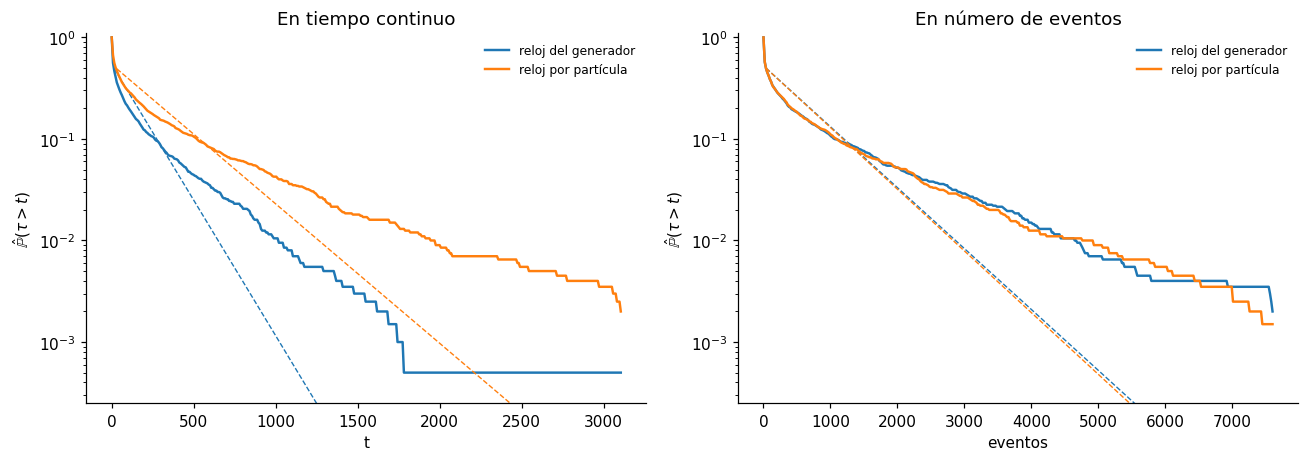

In [34]:
samples_clock = [extinction_sample(name, L_REF, init_single_particle, kill_tree, R_REF, master_seed=SEED + 400, clock=clk)
                 for name, clk in [("reloj del generador", "generator"), ("reloj por partícula", "per_particle")]]
print("En tiempo continuo:");   rows_clock_t = print_summary(samples_clock, scale="time")
print("\nEn número de eventos:"); rows_clock_e = print_summary(samples_clock, scale="events")
print(f"\ncociente de tasas en tiempo: {rows_clock_t[0]['gamma'] / rows_clock_t[1]['gamma']:.2f}"
      f"   en eventos: {rows_clock_e[0]['gamma'] / rows_clock_e[1]['gamma']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
plot_survival(axes[0], samples_clock, scale="time"); axes[0].set_title("En tiempo continuo")
plot_survival(axes[1], samples_clock, scale="events"); axes[1].set_title("En número de eventos")
plt.tight_layout(); plt.show()

### 8.8 Dimensión: $\mathbb{Z}^2$ vs. $\mathbb{Z}^3$

En $\mathbb{Z}^3$ la extinción es mucho más lenta (§6). Por eso medimos la probabilidad acumulada $\mathbb{P}(\tau\le t)$ hasta un horizonte fijo $t_{\max}$, para cajas pequeñas $L\in\{2,3,4\}$ en ambas dimensiones, con una partícula inicial y absorción en un árbol. Las réplicas que no se extinguen antes de $t_{\max}$ quedan censuradas.

experimento                        R  ‖θ0‖₁ P(ext)      E[τ]  mediana               γ̂₅₀ (IC 95%)     γ̂₈₀     γ̂₉₅  máx‖θ‖₁   [τ en t]
Z2, L=2                          200    1.0  1.000       3.1      1.5   0.2428    (0.1994–0.3155)   0.1869   0.2156      1.1
Z2, L=3                          200    1.0  1.000       7.1      2.6   0.0944    (0.0707–0.1345)   0.0648   0.0387      1.7
Z2, L=4                          200    1.0  1.000      11.9      5.0   0.0588    (0.0456–0.0823)   0.0431   0.0249      2.2
experimento                        R  ‖θ0‖₁ P(ext)      E[τ]  mediana               γ̂₅₀ (IC 95%)     γ̂₈₀     γ̂₉₅  máx‖θ‖₁   [τ en t]
Z3, L=2                          200    1.0  0.980 ≥    53.7     29.4   0.0137    (0.0111–0.0174)   0.0118   0.0085     10.0
Z3, L=3                          200    1.0  0.100 ≥   270.2    300.0      n/d                         n/d      n/d     40.6
Z3, L=4                          200    1.0  0.095 ≥   271.6    300.0      n/d                         

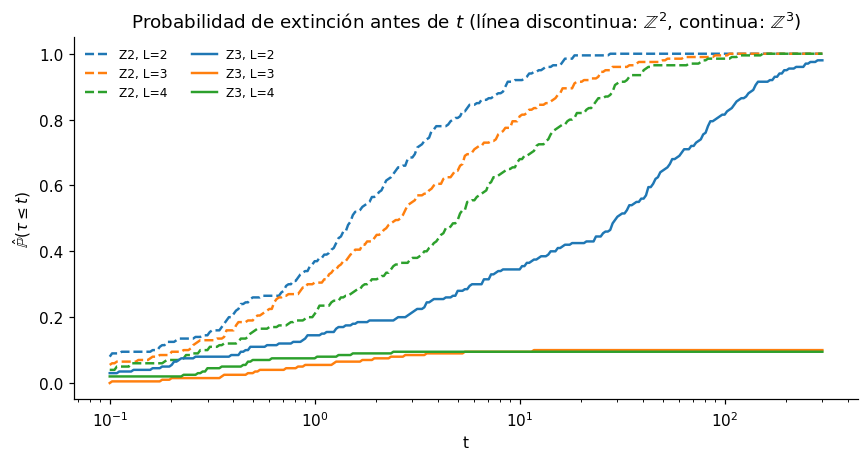

In [35]:
L_DIM = [2, 3, 4]
T_MAX_DIM = 300.0
R_DIM = 200
samples_dim = {
    d: [extinction_sample(f"Z{d}, L={L}", (L,) * d, init_single_particle, kill_tree, R_DIM,
                          master_seed=SEED + 500 + 10 * d + L, t_max=T_MAX_DIM)
        for L in L_DIM]
    for d in (2, 3)
}
for d in (2, 3):
    print_summary(samples_dim[d])

grid = np.geomspace(0.1, T_MAX_DIM, 300)
fig, ax = plt.subplots(figsize=(8, 4.3))
for d, ls in [(2, "--"), (3, "-")]:
    for k, s in enumerate(samples_dim[d]):
        ax.semilogx(grid, 1 - survival_function(s.tau, s.extinct, grid), ls=ls, color=f"C{k}", lw=1.6, label=s.label)
ax.set_xlabel("t"); ax.set_ylabel(r"$\hat{\mathbb{P}}(\tau\leq t)$")
ax.set_title(r"Probabilidad de extinción antes de $t$ (línea discontinua: $\mathbb{Z}^2$, continua: $\mathbb{Z}^3$)")
ax.legend(frameon=False, fontsize=8, ncol=2); plt.tight_layout(); plt.show()

### 8.9 Mapa conjunto: tamaño de caja × número de partículas

Para cada combinación de $L\in\{6,\dots,16\}$ y $N\in\{1,4,16,64\}$ (partículas $+1$), con $R=400$ réplicas, mostramos tres mapas:

- la mediana de $\tau$;
- la tasa de la cola $\hat\gamma$;
- la probabilidad de extinguirse antes de $t^\ast=100$.

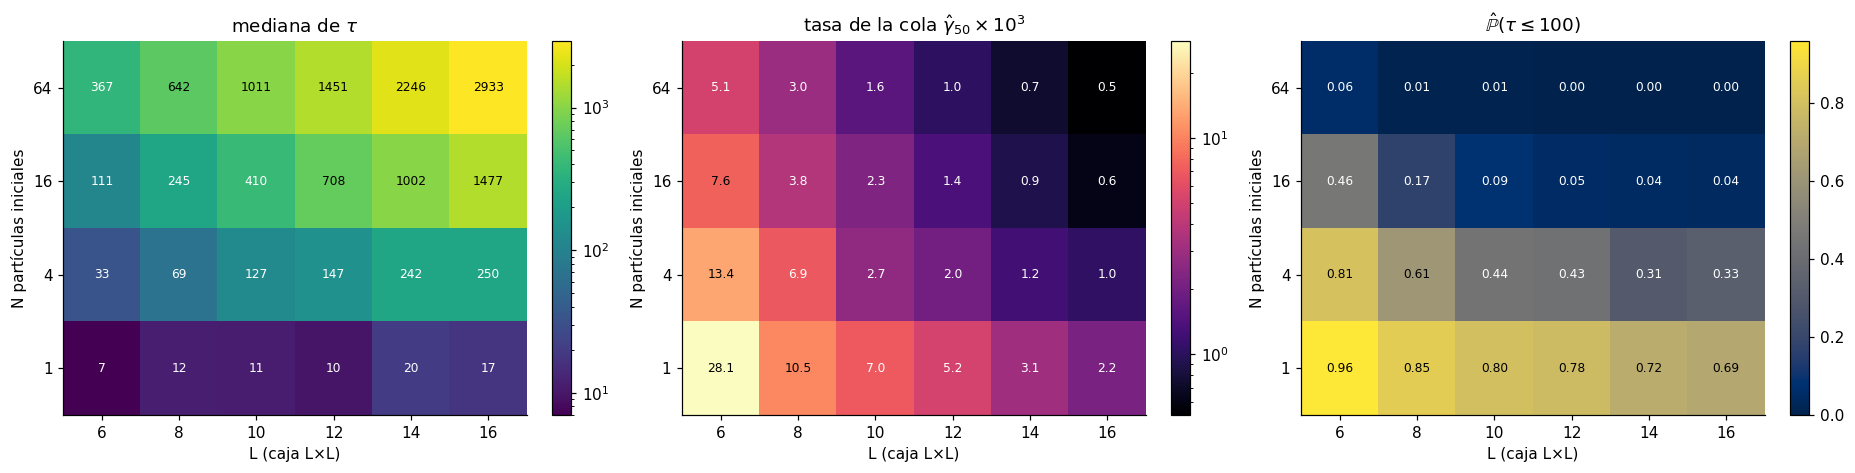

In [36]:
HEAT_L = [6, 8, 10, 12, 14, 16]
HEAT_N = [1, 4, 16, 64]
R_HEAT = 400
T_STAR = 100.0
heat = {key: np.zeros((len(HEAT_N), len(HEAT_L))) for key in ["median", "gamma", "p_star"]}
for j, L in enumerate(HEAT_L):
    for i, n in enumerate(HEAT_N):
        s = extinction_sample(f"L={L}, N={n}", (L, L), partial(init_random_particles, n=n, signed=False), kill_tree,
                              R_HEAT, master_seed=SEED + 10_000 + 100 * L + n)
        heat["median"][i, j] = np.median(s.tau)
        heat["gamma"][i, j] = tail_rate_mle(s.tau, s.extinct)
        heat["p_star"][i, j] = np.mean(s.extinct & (s.tau <= T_STAR))


def draw_heatmap(ax, values, title, fmt, cmap, log=False):
    """Mapa de calor anotado con ejes L (columnas) y N (filas)."""
    from matplotlib.colors import LogNorm
    im = ax.imshow(values, cmap=cmap, origin="lower", aspect="auto", norm=LogNorm() if log else None)
    ax.set_xticks(range(len(HEAT_L)), HEAT_L); ax.set_yticks(range(len(HEAT_N)), HEAT_N)
    ax.set_xlabel("L (caja L×L)"); ax.set_ylabel("N partículas iniciales"); ax.set_title(title)
    for (i, j), v in np.ndenumerate(values):
        r, g, b, _ = im.cmap(im.norm(v))
        ax.text(j, i, format(v, fmt), ha="center", va="center", fontsize=8,
                color="white" if 0.299 * r + 0.587 * g + 0.114 * b < 0.55 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)


fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
draw_heatmap(axes[0], heat["median"], r"mediana de $\tau$", ".0f", "viridis", log=True)
draw_heatmap(axes[1], 1e3 * heat["gamma"], r"tasa de la cola $\hat\gamma_{50}\times 10^{3}$", ".1f", "magma", log=True)
draw_heatmap(axes[2], heat["p_star"], rf"$\hat{{\mathbb{{P}}}}(\tau\leq {T_STAR:.0f})$", ".2f", "cividis")
plt.tight_layout(); plt.show()

### 8.10 Conclusiones

1. **Con el árbol fijo, el régimen es cuasi-estacionario (8.2).** Para un árbol dado, las tasas en la cola profunda ($\hat\gamma_{80}$, $\hat\gamma_{95}$) coinciden entre condiciones iniciales dentro del error estadístico: $\approx0.0035$–$0.004$ en el árbol 0 y $\approx0.010$–$0.012$ en el árbol 2. La condición inicial solo cambia el prefactor $C(\theta_0)$, es decir, cuánto se tarda en llegar al régimen exponencial.
   - El caso extremo es el lazo $\partial f$, que se extingue en el primer evento con probabilidad $\approx\tfrac12$ (mediana $0.3$). Esto ocurre cuando la cara que suena es la misma $f$, porque entonces $\theta-\partial f=0$.
   - Su cola residual converge a la misma tasa: $\hat\gamma_{50}\to\hat\gamma_{80}\to\hat\gamma_{95}$ baja hacia la tasa del árbol.

2. **La tasa de extinción es la constante de Poincaré (8.3).** En 40 árboles aleatorios, $\gamma(T)$ varía en un factor $\approx 9$, y aun así sigue a $c'(T)$ con correlación $0.95$ y exponente $\approx1.07$. Es decir, empíricamente

   $$\gamma(T)\;\approx\;c'(T)=\lambda_{\min}\big(\Delta^\uparrow|_{E\setminus T}\big).$$

   Esto es coherente con el drift $\mathcal{L}I(\theta)=-\Delta^\uparrow_T\theta$: el modo más lento de la parte lineal decae como $e^{-c't}$, y la extinción ocurre a esa misma tasa. **Es una conjetura natural para el paper**, porque refina el Teorema 2.4 y la Observación 3 identificando la tasa exacta de la cola.

3. **Con el árbol aleatorio las colas son mezclas (8.1, 8.4).** Si se promedia sobre árboles, $S(t)=\mathbb{E}_T[C_Te^{-\gamma(T)t}]$ es convexa en escala semilogarítmica, y su cola la dominan los árboles con $c'(T)$ chico. Por eso la tasa efectiva $\hat\gamma_{50}$ baja cuando aumenta la masa inicial ($0.0057\to0.0016$ de $N=1$ a $N=64$): con más partículas, la supervivencia larga se concentra en los árboles lentos.

4. **Número de partículas (8.4).**
   - Con partículas $+1$, $\mathbb{E}[\tau_N]$ sigue muy de cerca la referencia de $N$ partículas independientes: el máximo de $N$ copias del tiempo de una partícula, que crece como $\log N/\gamma$. A esta escala la interacción entre partículas del mismo signo es débil.
   - Con signo $\pm1$ los tiempos son menores ($759$ contra $1097$ para $N=64$), porque parte de la masa se cancela al inicio y por aniquilación.

5. **Tamaño de la caja (8.5).**
   - $\hat\gamma_{50}\propto L^{-2.3}$ y $c'\propto L^{-2.9}$, con $\hat\gamma_{50}/c'\approx1$ hasta $L=12$.
   - Para $L$ grande la tasa efectiva supera a $c'$ promedio. Es otra vez el efecto de mezcla: el promedio de $c'$ y la tasa de la mezcla no son la misma cantidad.
   - La mediana de $\tau$ crece poco con $L$ (de $4$ a $\approx18$), porque la mayoría de las partículas mueren rápido cerca del árbol; lo que crece es la cola.

6. **Conjunto absorbente (8.6).** Agregar aristas absorbentes acelera la extinción de forma monótona: con el árbol más 50 % de aristas extra, $\hat\gamma_{50}$ es 7 veces mayor. Llama la atención que, partiendo de un lazo (divergencia nula), absorber solo en el borde de la caja (18 % de las aristas) extingue *más rápido* que el árbol (55 %).
   - *Hipótesis:* el árbol "corta" los lazos y deja cadenas abiertas, cuyos extremos tienen divergencia. Esos extremos solo desaparecen al llegar a $T$.
   - En cambio, con absorción en el borde la divergencia se conserva igual a $0$, y la configuración sigue siendo el borde de una región de alturas que puede colapsar.

7. **El reloj solo cambia la escala de tiempo (8.7).** Medido en eventos, las dos versiones son indistinguibles (cociente de tasas $0.99$). En tiempo continuo, las tasas difieren en un factor $1.95\approx\lambda_e=2$, como se esperaba.

8. **Dimensión (8.8).** En $\mathbb{Z}^2$ la extinción es segura y rápida en cajas pequeñas. En $\mathbb{Z}^3$, ya con $L=3$ solo el $\approx10\%$ de las réplicas se extingue antes de $t=300$, y casi todas lo hacen en los primeros instantes, antes de ramificarse. Las que sobreviven al comienzo entran en la meseta cuasi-estacionaria de §6, consistente con una $c'$ muy pequeña en 3D.

9. **Mapa $L\times N$ (8.9).** La probabilidad de extinguirse antes de $t^\ast=100$ cae rápido con ambos factores: de $0.96$ ($L=6$, $N=1$) a $\approx0$ ($N=64$). Para $N=64$, la mediana de $\tau$ crece aproximadamente como $L^2$: de $367$ a $2933$ entre $L=6$ y $L=16$.

## Referencias

- D. Cid, A. Sepúlveda. *Branching process on complexes*, borrador V1 (2026).
- S. Mukherjee, J. Steenbergen. *Random walks on simplicial complexes and harmonics*, Random Structures & Algorithms (2016).
- A. M. Duval, C. J. Klivans, J. L. Martin. *Simplicial matrix-tree theorems*, Trans. AMS (2009).
- T. M. Liggett. *Interacting Particle Systems*, Springer (1985/2005).
- D. T. Gillespie. *Exact stochastic simulation of coupled chemical reactions*, J. Phys. Chem. (1977).
- P. Collet, S. Martínez, J. San Martín. *Quasi-Stationary Distributions*, Springer (2013).